# Chapter 8 Vision–Language Models

## Learning Objectives

After completing this chapter, you should be able to:

1. Explain the two dominant VLM architecture families:
   - **Dual-encoder contrastive** (CLIP-like) and why it enables *retrieval* and *zero-shot classification*.
   - **Fusion / encoder–decoder** (cross-attention + generation) and why it enables *captioning, VQA, instruction following*.
2. Describe the role of **paired image–text data** (web-scale vs curated), and how data noise affects learning.
3. Compare VLM evaluation axes beyond a single benchmark:
   - retrieval metrics (Recall@K), zero-shot accuracy, robustness, bias/fairness, efficiency (latency/memory/energy).
4. Derive the CLIP-style similarity matrix $$s_{ij} = \frac{v_i^\top t_j}{\tau}$$ and the symmetric contrastive loss.
5. Interpret CLIP gradients as **positive pull** toward matched pairs and **negative push** away from batch negatives.
6. Explain why **temperature / logit scale** changes optimization dynamics and hard-negative emphasis.
7. Write down the conditional generation objective for fusion models:
   $$
   \max_\psi \sum_{i=1}^{N} \log p_\psi(y_i \mid x_i).
   $$
8. Implement a **simple CLIP-like** model (dual encoders + symmetric contrastive loss) end-to-end.
9. Visualize a joint embedding space using **t-SNE** and interpret where images, captions, and prompts land.
10. Use a **pretrained CLIP** implementation for:
    - embedding extraction,
    - zero-shot classification,
    - text→image retrieval,
    - t-SNE visualization of pretrained embeddings.
11. Distill a large **teacher CLIP** into a **small student CLIP** using:
    - embedding regression,
    - similarity-matrix KL distillation,
    and validate that the student preserves CLIP-like behavior.
12. Implement a **fusion-based encoder–decoder** VLM on MNIST for comparison and explain how cross-attention differs from dual encoders.
13. Identify key systems and research directions:
    - scaling and data (CLIP, ALIGN, OpenCLIP, DataComp),
    - alternative objectives (SigLIP),
    - adaptation (CoOp / adapters),
    - dense prediction and localization (e.g., OWL-ViT / Grounding DINO),
    - multimodal LLMs (BLIP-2, Flamingo, LLaVA),
    - small/efficient models (TinyCLIP, MobileCLIP).

## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

## What are Vision–Language Models?

Vision–Language Models (VLMs) learn to connect **visual semantics** (objects, actions, relations) with **linguistic semantics** (words, phrases, sentences).  
They support tasks where *either modality can query the other*. For example, given "a small cat," a VLM will generate the image of a cat and given the image of a act, a VLM will create its caption or description in text. 

**short history until 2022** https://lilianweng.github.io/posts/2022-06-09-vlm/


### Why are VLMs important?

Classic vision models are typically trained on fixed label sets. VLMs instead use **language supervision**, enabling:

- **Open-vocabulary recognition** (classify with arbitrary text labels)
- **Cross-modal retrieval** (text → images, image → text)
- **Grounding** (link phrases to regions; when the model supports it)
- **Generative multimodal systems** (captioning, instruction following, VQA)

A key shift is that language enables **flexible, compositional supervision** instead of fixed-category labels.

### Training data

Most VLMs are trained on paired data:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N},
$$

where $x_i$ is an image (or video) and $y_i$ is associated text (caption/alt-text/metadata/instructions).

At web scale, pairs are noisy, and modern VLM performance is shaped by the combination of:
- objective design,
- model capacity,
- data quality, diversity, and filtering.


## Two dominant architecture families

### Dual-encoder (contrastive) VLMs — *CLIP-like*

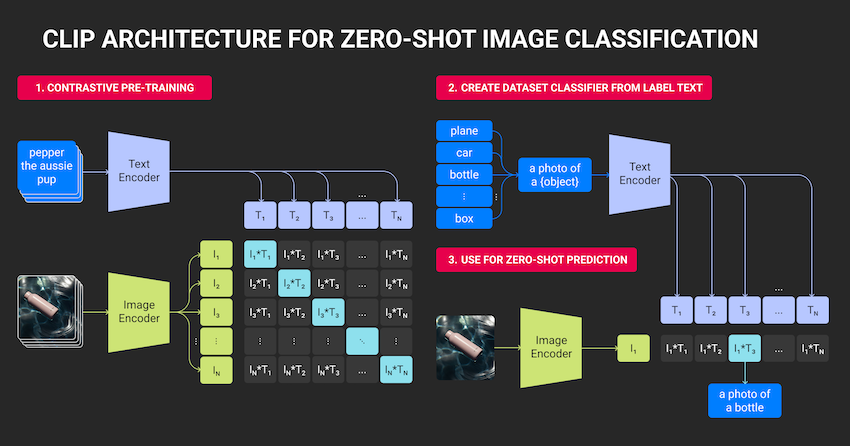

Source: https://labelyourdata.com/articles/machine-learning/vision-language-models

Two separate encoders map each modality to a shared embedding space:

- Image encoder: $f_\theta(x) \in \mathbb{R}^d$  
- Text encoder: $g_\phi(y) \in \mathbb{R}^d$ 

Typically we L2-normalize:

$$
v = \frac{f_\theta(x)}{\lVert f_\theta(x)\rVert}, \quad
t = \frac{g_\phi(y)}{\lVert g_\phi(y)\rVert}
$$

Similarity (cosine similarity with temperature):

$
s(x,y) = \frac{v^\top t}{\tau}
$

Whare $\tau$ is the temperature. 

**Strengths**
- Extremely efficient retrieval (cache embeddings; use ANN search)
- Zero-shot classification via prompt embeddings
- Scales well

**Limitations**
- Global alignment can miss fine-grained spatial grounding unless extended (e.g., region features or token-level alignment)
- Harder to do multi-step reasoning *without* a generative/fusion component

### Fusion / encoder–decoder VLMs — *cross-attention + generation*

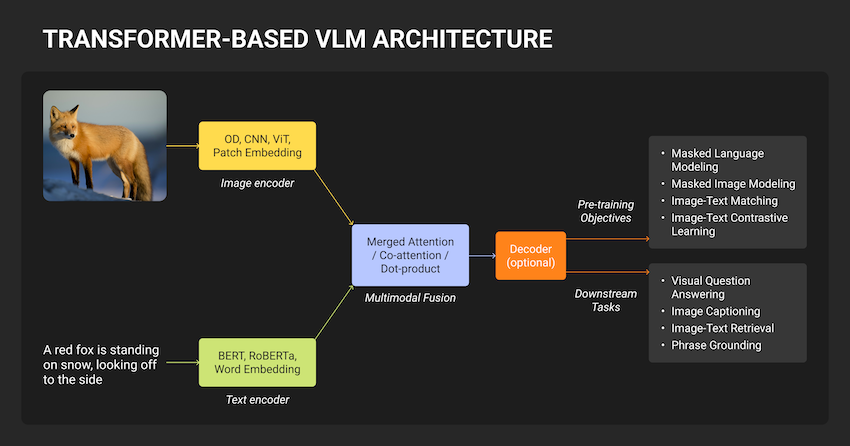

Source: https://labelyourdata.com/articles/machine-learning/vision-language-models

These models fuse visual tokens with text tokens inside a Transformer (single-stream or with cross-attention).  
Often trained with conditional generation objectives such as:

$$
\max_\psi \sum_{i=1}^{N} \log p_\psi(y_i \mid x_i).
$$

**Strengths**
- Strong for captioning, VQA, instruction following, multi-step reasoning
- Can incorporate region-level tokens and explicit grounding more naturally

**Limitations**
- Typically more expensive inference than dual encoders
- More prone to **hallucination** (generating plausible but unsupported details) if alignment is imperfect

### CLIP: Core idea and objective

CLIP (Contrastive Language–Image Pretraining) is a dual-encoder model trained so that **matching image–text pairs** have high similarity, and **mismatched pairs** have lower similarity.

#### What is trained?

A CLIP-like dual encoder has two neural networks:

- **Image encoder** with parameters $\theta_I$:
$$
v_i = f_{\theta_I}(x_i)\in\mathbb{R}^d
$$

- **Text encoder** with parameters $theta_T$:
$$
t_j = g_{\theta_T}(y_j)\in\mathbb{R}^d
$$

Usually we **L2-normalize** the embeddings:

$$
\hat v_i=\frac{v_i}{\|v_i\|},\qquad \hat t_j=\frac{t_j}{\|t_j\|}.
$$

We also use a temperature $tau>0$ (often learned via a logit-scale parameter).

### Trainable parameters
The learnable parameters are:

$$
\theta = \{\theta_I,\theta_T,\tau\}.
$$

### Loss formulation (image $to$ text)
Given a batch of \(B\) matched pairs $(x_i,y_i)$, define the similarity scores:

$$
s_{ij}=\frac{\hat v_i^\top \hat t_j}{\tau}.
$$

Define the **row-softmax** probabilities (softmax over $j$, holding $i$ fixed):

$$
p_{ij}=\mathrm{softmax}_j(s_{ij})
=\frac{\exp(s_{ij})}{\sum_{k=1}^{B} \exp(s_{ik})}.
$$

For each image $i$, $p_{ij}$ is the model’s predicted probability that image $i$ matches text $j$, **treating the batch texts as the candidate classes**.

So for each fixed image $i$:

$$
\sum_{j=1}^B p_{ij}=1,\qquad p_{ij}\ge 0.
$$

### Image-to-text loss
The image-to-text contrastive loss is cross-entropy where the correct class for image $i$ is text $i$ where $i$ represents an $(image, text)$ pair:

$$
\mathcal{L}_{I\to T}
=
\frac{1}{B}\sum_{i=1}^B \left[-\log p_{ii}\right]
=
\frac{1}{B}\sum_{i=1}^B
\left[
-\log
\frac{\exp(s_{ii})}{\sum_{j=1}^B\exp(s_{ij})}
\right].
$$

### Learning - the update rule using gradient descent

With learning rate $eta$, gradient descent updates parameters as:

$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}.
$$

Concretely:

$$
\theta_I \leftarrow \theta_I - \eta \frac{\partial \mathcal{L}}{\partial \theta_I},
\qquad
\theta_T \leftarrow \theta_T - \eta \frac{\partial \mathcal{L}}{\partial \theta_T}.
$$

To compute $\frac{\partial \mathcal{L}}{\partial \theta_I}$, we use the chain rule:

$$
\frac{\partial \mathcal{L}}{\partial \theta_I}
=
\sum_{i=1}^B
\frac{\partial \mathcal{L}}{\partial \hat v_i}
\frac{\partial \hat v_i}{\partial \theta_I}.
$$

So the key step is first deriving $\frac{\partial \mathcal{L}}{\partial \hat v_i}$.

Define the per-image loss:

$$
\ell_i = -\log p_{ii}.
$$

A standard softmax + cross-entropy identity gives:

$$
\frac{\partial \ell_i}{\partial s_{ij}} = p_{ij} - \mathbf{1}[j=i].
$$

Interpretation:
- For the positive class $j=i$, the derivative is $p_{ii}-1$.
- For a negative $j\neq i$, the derivative is $p_{ij}$.

We have:

$$
s_{ij}=\frac{\hat v_i^\top \hat t_j}{\tau}.
$$

Therefore:

$$
\frac{\partial s_{ij}}{\partial \hat v_i}=\frac{1}{\tau}\hat t_j.
$$

Applying the chain rule:

$$
\frac{\partial \ell_i}{\partial \hat v_i}
=
\sum_{j=1}^B
\frac{\partial \ell_i}{\partial s_{ij}}
\frac{\partial s_{ij}}{\partial \hat v_i}
=
\sum_{j=1}^B
\left(p_{ij}-\mathbf{1}[j=i]\right)\frac{1}{\tau}\hat t_j.
$$

Split the sum into the $p_{ij}$ part and the indicator part:

$$
\frac{\partial \ell_i}{\partial \hat v_i}
=
\frac{1}{\tau}
\left(
\sum_{j=1}^B p_{ij}\hat t_j - \hat t_i
\right).
$$

Finally, since:

$$
\mathcal{L}_{I\to T} = \frac{1}{B}\sum_{i=1}^B \ell_i,
$$

By substituing we get:

$$
\frac{\partial \mathcal{L}_{I\to T}}{\partial \hat v_i}
=
\frac{1}{B\tau}
\left(
\sum_{j=1}^B p_{ij}\hat t_j - \hat t_i
\right).
$$

This is the expression is sometimes written with $\propto$ to hide the constants $(1/(B\tau)$).

#### Interpretation: pull–push geometry

Gradient descent uses:

$$
\hat v_i \leftarrow \hat v_i - \eta \frac{\partial \mathcal{L}_{I\to T}}{\partial \hat v_i}.
$$

So the **movement direction** is:

$$
-\frac{\partial \mathcal{L}_{I\to T}}{\partial \hat v_i}
\propto
\hat t_i - \sum_{j=1}^B p_{ij}\hat t_j.
$$

Meaning:

- **Pull** $\hat v_i$ toward the positive text embedding $\hat t_i$.
- **Push** $\hat v_i$ away from a soft mixture of texts $\sum_j p_{ij}\hat t_j$, where the weights $p_{ij}$ emphasize **hard negatives** (texts the model currently finds similar).

#### Temperature $\tau$
- Smaller $\tau$ makes the softmax distribution **peakier**, increasing focus on the hardest negatives.
- It also scales gradient magnitude by $1/\tau$.


### Final update w.r.t. network parameters

Once $\frac{\partial \mathcal{L}}{\partial \hat v_i}$ is known, the rest is standard backprop:

$$
\frac{\partial \mathcal{L}}{\partial \theta_I}
=
\sum_{i=1}^B
\frac{\partial \mathcal{L}}{\partial \hat v_i}
\frac{\partial \hat v_i}{\partial \theta_I}.
$$

PyTorch (or any autodiff engine) computes $\frac{\partial \hat v_i}{\partial \theta_I}$ automatically through the computation graph of $f_{\theta_I}$ and the L2-normalization.

The text side is analogous, and CLIP typically adds the symmetric **text-to-image** term $\mathcal{L}_{T\to I}$ as well.

Total (symmetric) loss:

$$
\mathcal{L} = \frac{1}{2}\left(\mathcal{L}_{I\to T} + \mathcal{L}_{T\to I}\right).
$$


### How CLIP is used: Zero-shot classification and retrieval

#### Zero-shot classification

Suppose you have a set of class names $\{c\}$ and you create text prompts for each class, e.g.:
- “a photo of a **{class}**”
- “an image of a **{class}**”

Compute a text embedding prototype for each class (often by averaging multiple prompts):

$$
w_c = \frac{1}{K}\sum_{k=1}^{K} \frac{g_\phi(\text{prompt}_k(c))}{\lVert g_\phi(\text{prompt}_k(c))\rVert}.
$$

Given an image embedding $v$, predict:

$$
\hat{c} = \arg\max_c \frac{v^\top w_c}{\tau}.
$$

This is why CLIP enables “open vocabulary” recognition: **your labels are text strings**.

#### Cross-modal retrieval

Given a query text embedding $t_q$, retrieve images whose embeddings $v$ maximize $v^\top t_q$.  
Given an image query embedding $v_q$, retrieve texts maximizing $v_q^\top t$.

#### Prompt engineering and calibration (practical notes)

- Prompt templates can materially change results.
- Prompt ensembling (multiple templates) often improves zero-shot accuracy.
- Domain shift can be mitigated by:
  - better prompts,
  - few-shot adaptation,
  - or lightweight fine-tuning (e.g., LoRA, adapters) depending on the use case.

## Simple CLIP Implementation

To make CLIP concrete, we will implement a **small** CLIP-style dual encoder and train it on MNIST digits paired with synthetic captions like:

- “a photo of the digit 7”
- “handwritten number seven”

This is not intended to match real CLIP performance but an example that.
- builds the similarity matrix $s_{ij}$
- applies the symmetric contrastive loss
- demonstrates zero-shot classification and retrieval

> If MNIST download fails (network restrictions), you can point `root` to a local cached dataset.

In [ ]:
# Core imports (minimal)
import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np

# Try importing torch/torchvision
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    import torchvision
    from torchvision import transforms
except Exception as e:
    raise RuntimeError(
        "PyTorch + torchvision are required for the code sections. "
        "Install them first, e.g., via pip/conda, then re-run this cell.\n\n"
        f"Original import error: {e}"
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:
# MNIST + synthetic caption dataset

DIGIT_WORDS = ["zero","one","two","three","four","five","six","seven","eight","nine"]

# create sentences like "a photo of the digit three" or "handwritten digit seven"
# to match with the image of the digit in the MNIST dataset. 
# This is a simple way to create a vision-language dataset for testing CLIP-like 
# models on a small scale.

TEMPLATES = [
    "a photo of the digit {}",
    "a picture of the number {}",
    "handwritten digit {}",
    "this is the digit {}",
    "the number {}",
    "an image of {}",
    "a handwritten {}",
]

# Given a digit label (0-9), randomly choose a template and fill in the word for that digit.
def make_caption(label: int) -> str:
    w = DIGIT_WORDS[label]
    tpl = random.choice(TEMPLATES)
    return tpl.format(w)

# This dataset class wraps the MNIST dataset and adds a synthetic caption for each image 
# based on its label.
class MNISTCaptionDataset(Dataset):
    def __init__(self, root="./data_mnist", train=True, max_items=None):
        self.transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))  # map roughly to [-1, 1]
        ])
        self.ds = torchvision.datasets.MNIST(
            root=root, train=train, download=True, transform=self.transform
        )
        self.max_items = max_items

    def __len__(self):
        n = len(self.ds)
        return min(n, self.max_items) if self.max_items is not None else n

    def __getitem__(self, idx):
        x, y = self.ds[idx]
        caption = make_caption(int(y))
        return x, int(y), caption

# Build a small train/test subset for fast demo
train_ds = MNISTCaptionDataset(train=True, max_items=12000)
test_ds  = MNISTCaptionDataset(train=False, max_items=2000)

print("Train size:", len(train_ds), "Test size:", len(test_ds))

### A tiny tokenizer (word-level)

Real CLIP uses a BPE tokenizer and a Transformer text encoder.  For this simple example, we use a **simple word tokenizer** over our caption templates.

- Build a vocabulary from the dataset captions
- Convert captions to token IDs
- Pad/truncate to a fixed length

This keeps the code minimal while preserving the “text encoder → embedding” structure.


In [ ]:
# Tokenizer utilities

# A very basic tokenizer that lowercases, removes punctuation, and splits on whitespace.
def basic_tokenize(s: str) -> List[str]:
    s = s.lower().replace(".", "").replace(",", "")
    return s.split()

# A simple vocab class that maps tokens to IDs and vice versa, with special tokens for 
# padding and unknown words.
@dataclass
class SimpleVocab:
    stoi: Dict[str, int]
    itos: List[str]
    pad_id: int
    unk_id: int

def build_vocab(samples: List[str], min_freq: int = 1) -> SimpleVocab:
    from collections import Counter
    c = Counter()
    for s in samples:
        c.update(basic_tokenize(s))
    itos = ["<pad>", "<unk>"]
    for tok, freq in c.most_common():
        if freq >= min_freq and tok not in itos:
            itos.append(tok)
    stoi = {t:i for i,t in enumerate(itos)}
    return SimpleVocab(stoi=stoi, itos=itos, pad_id=stoi["<pad>"], unk_id=stoi["<unk>"])

def encode_text(vocab: SimpleVocab, s: str, max_len: int = 16) -> torch.Tensor:
    toks = basic_tokenize(s)
    ids = [vocab.stoi.get(t, vocab.unk_id) for t in toks][:max_len]
    if len(ids) < max_len:
        ids += [vocab.pad_id] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)

# Build vocab from a sample of training captions (fast)
sample_caps = [train_ds[i][2] for i in range(min(5000, len(train_ds)))]
vocab = build_vocab(sample_caps, min_freq=1)
print("Vocab size:", len(vocab.itos))
print("Example:", sample_caps[0], "->", encode_text(vocab, sample_caps[0]))


In [ ]:
# Collate function and dataloaders

from torch.utils.data import DataLoader
from torchvision import transforms

MAX_LEN = 16

# collate_fn takes a list of samples (x, y, caption) and processes them into batched tensors.

def collate_fn(batch):
    # batch is a list of tuples (x, y, caption)
    # where x is a PIL image (or tensor), y is an int label, and caption is a string.
    xs, ys, caps = zip(*batch)

    # If the dataset returns PIL images (no transform), convert them here.
    xs = [x if torch.is_tensor(x) else transforms.ToTensor()(x) for x in xs]

    x = torch.stack(xs, dim=0)  # (B, 1, H, W)
    y = torch.tensor(ys, dtype=torch.long)
    t = torch.stack([encode_text(vocab, c, max_len=MAX_LEN) for c in caps], dim=0).long()

    return x, y, t, list(caps)

# NOTE:
# In Jupyter (especially on macOS/Windows), num_workers>0 can cause multiprocessing/pickling issues.
# Start with num_workers=0 for reliability; increase to 2/4 only if it works in your environment.
num_workers = 8 # later change it so zero 
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
    drop_last=True,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
    drop_last=False,
    pin_memory=pin_memory,
)

xb, yb, tb, caps_b = next(iter(train_loader))
print("x:", xb.shape, "y:", yb.shape, "t:", tb.shape, "example cap:", caps_b[0])


### A Minimal CLIP-like model

We define:
- a small CNN image encoder
- a small Transformer text encoder
- projection heads to a shared embedding dimension
- a learnable temperature parameter

We then compute the similarity matrix $s_{ij}$ and apply symmetric contrastive loss.


In [ ]:
# Minimal CLIP-like model (CNN + Transformer)

class TinyImageEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()

        # A simple CNN that takes (B, 1, 32, 32) and produces (B, out_dim).
        # Encodes each image into a feature vector. 
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        z = self.proj(h)
        return z

class TinyTextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, out_dim=128, max_len=16):
        super().__init__()
        # A simple Transformer encoder that takes (B, T) token IDs and produces (B, out_dim).
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=4*d_model, batch_first=True)
        self.enc = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.proj = nn.Linear(d_model, out_dim)

    def forward(self, token_ids, pad_id: int):
        # token_ids: (B, T)
        B, T = token_ids.shape
        # Embed tokens and add positional embeddings
        x = self.tok_emb(token_ids) + self.pos_emb[:, :T, :]
       
        # key padding mask: True for pads
        # this is needed to tell the Transformer to ignore pad tokens in attention and pooling.
        # pad tokens are those where token_ids == pad_id, so we create a boolean mask for that.
        key_padding_mask = (token_ids == pad_id)
        
        # .enc will use the key_padding_mask to ignore pads in attention.
        h = self.enc(x, src_key_padding_mask=key_padding_mask)  # (B, T, d_model)

        # Simple pooling: take first token (like a CLS, though we didn't insert one),
        # or use masked mean. We'll use masked mean for stability.
        mask = (~key_padding_mask).float().unsqueeze(-1)  # (B, T, 1)
        h_mean = (h * mask).sum(dim=1) / (mask.sum(dim=1).clamp_min(1.0))
        z = self.proj(h_mean)
        return z

class TinyCLIP(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, max_len=16):
        super().__init__()
        self.image = TinyImageEncoder(out_dim=embed_dim)
        self.text  = TinyTextEncoder(vocab_size=vocab_size, d_model=embed_dim, out_dim=embed_dim, max_len=max_len)
        # Learnable logit scale (temperature inverse)
        # Initialized to log(1/0.07) ~ 2.66, which is a common starting point for CLIP models.
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1/0.07)))  # ~ CLIP init

    def forward(self, images, token_ids, pad_id):
        # images: (B, 1, H, W), token_ids: (B, T)
        v = self.image(images)
        # text encoder will ignore pads in attention and pooling, 
        # so we can just pass token_ids and pad_id.
        t = self.text(token_ids, pad_id=pad_id)

        # Normalize to unit vectors for cosine similarity
        v = F.normalize(v, dim=-1)
        t = F.normalize(t, dim=-1)

        # Compute cosine similarity and scale by logit_scale (temperature inverse)
        # clamp logit_scale to prevent overflow in exp/logit scaling
        logit_scale = self.logit_scale.exp().clamp(max=100.0)
        logits = logit_scale * (v @ t.t())  # (B, B)

        # logits[i,j] = logit_scale * cosine_similarity(image_i, text_j)
        # which is the similarity score that CLIP uses for contrastive learning.
        return logits

def clip_loss(logits):
    # symmetric loss: CE over rows and columns
    # For each image (row), the correct text is the one with the same index 
    # (diagonal), and vice versa for texts (columns).
    # B is the batch size, which is also the number of image-text pairs in the batch.
    B = logits.size(0)
    
    # targets are just 0, 1, ..., B-1 for both image-to-text and text-to-image.
    # arrange targets as a tensor of shape (B,) where targets[i] = i, 
    # meaning the correct match for image i is text i.
    targets = torch.arange(B, device=logits.device)
    
    # Compute cross-entropy loss for image-to-text (logits) and text-to-image (logits.t())
    # dimensions of loss_i is (B,) where loss_i[i] is the loss for image i matching text 
    # targets[i].
    loss_i = F.cross_entropy(logits, targets)
    # Computer cross-entropy loss for text-to-image (logits.t()) and targets.
    loss_t = F.cross_entropy(logits.t(), targets)
    
    # return the avarage of the two losses, which is the symmetric CLIP loss.
    return 0.5 * (loss_i + loss_t)

# vocab.itos is the list of tokens in the vocab, so len(vocab.itos) gives the vocab size.
model = TinyCLIP(vocab_size=len(vocab.itos), embed_dim=128, max_len=MAX_LEN).to(device)
print(model)


### Training

We train briefly to show that the contrastive objective learns alignment.

> For a real experiment you would train longer and tune hyperparameters, but this is designed to run quickly.


In [ ]:
# Training loop

def run_epoch(model, loader, opt=None):
    train = opt is not None
    # Set model to train or eval mode based on whether opt is provided.
    model.train(train)
    total_loss = 0.0
    n = 0
    # Loop over batches from the loader. 
    # Each batch gives us x (images), y (labels), t_ids (token ids), and caps (captions).
    for x, y, t_ids, caps in loader:
        # Move x and t_ids to the device (GPU/CPU) before passing to the model.
        x = x.to(device)
        t_ids = t_ids.to(device)

        # Compute logits and loss using the model and clip_loss function.
        logits = model(x, t_ids, pad_id=vocab.pad_id)
        loss = clip_loss(logits)

        if train:
            # Backpropagation and optimization step
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / max(n, 1)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

EPOCHS = 30  # increase if you want
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(model, train_loader, opt=opt)
    te = run_epoch(model, test_loader,  opt=None)
    print(f"Epoch {epoch:02d} | train loss {tr:.4f} | test loss {te:.4f} | logit_scale {model.logit_scale.exp().item():.2f}")


### Zero-shot classification using CLIP

Even though our training uses captions, we can attempt **zero-shot** classification by creating one prompt per class and selecting the class with highest similarity.

We use a single template:
- “a photo of the digit {word}”

For each class $c$:
- compute text embedding $w_c$
- for each image embedding $v$, choose $\hat{c}=\arg\max_c v^\top w_c$

In [ ]:
# Zero-shot evaluation on the test set

@torch.no_grad()
def encode_image_batch(model, x):
    # Encode a batch of images into their feature vectors using the model's image encoder.
    v = model.image(x)
    # Normalize the image features to unit vectors for cosine similarity.
    # dim= -1 means we normalize across the feature dimension, so each vector becomes 
    # a unit vector.
    return F.normalize(v, dim=-1)

@torch.no_grad()
def encode_text_prompts(model, prompts: List[str]):
    # Encode a list of text prompts into their feature vectors using the model's text encoder.
    # stack the encoded prompts into a tensor of shape (num_prompts, max_len) and move to device.
    t_ids = torch.stack([encode_text(vocab, p, max_len=MAX_LEN) for p in prompts], dim=0).to(device)
    
    # Encode the text prompts using the model's text encoder, which 
    # will ignore pads in attention and pooling.
    t = model.text(t_ids, pad_id=vocab.pad_id)
    return F.normalize(t, dim=-1)

# Build class prompts
class_prompts = [f"a photo of the digit {DIGIT_WORDS[i]}" for i in range(10)]

# Encode the class prompts into their feature vectors using the model's text encoder.
W = encode_text_prompts(model, class_prompts)  # (10, d)

@torch.no_grad()
def zero_shot_accuracy(model, loader):
    correct = 0
    total = 0
    
    # Loop over batches from the loader. For each batch, we will encode the images and 
    # compute the cosine similarity with the class prompts to get predictions, 
    # then compare with the true labels to count correct predictions.

    for x, y, t_ids, caps in loader:
        x = x.to(device)
        y = y.to(device)
        V = encode_image_batch(model, x)         # (B, d)

        # Compute cosine similarity with class prompts W to get logits for each class.
        logits = V @ W.t()                       # (B, 10) (temperature not needed for argmax)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)

acc = zero_shot_accuracy(model, test_loader)
print("Toy zero-shot accuracy:", acc)
print("Class prompts:", class_prompts[:3], "...")


### Cross-modal retrieval using CLIP

We demonstrate:
- **Text → Image** retrieval: given a prompt, find nearest images
- **Image → Text** retrieval: given an image, find nearest captions within a batch

This illustrates how dual encoders support retrieval naturally.


In [ ]:
! pip install matplotlib

In [ ]:
# Text to Image Retrieval

import matplotlib.pyplot as plt

@torch.no_grad()
def show_text_to_image(model, loader, query: str, k: int = 6):
    # Grab one batch and rank images by similarity to query
    x, y, t_ids, caps = next(iter(loader))
    x = x.to(device)

    V = encode_image_batch(model, x)  # (B, d)
    tq = encode_text_prompts(model, [query])[0]  # (d,)
    scores = (V @ tq).detach().cpu().numpy()

    # find the top-k indices with highest scores (most similar to query)
    idx = np.argsort(-scores)[:k]

    fig, axes = plt.subplots(1, k, figsize=(2.2*k, 2.2))
    fig.suptitle(f"Text→Image retrieval for: '{query}'", y=1.15)
    for ax, i in zip(axes, idx):
        img = x[i].detach().cpu()
        # unnormalize for display (rough)
        img_disp = (img * 0.5 + 0.5).clamp(0, 1)
        ax.imshow(img_disp.squeeze(0), cmap="gray")
        ax.set_title(f"y={y[i]}\nscore={scores[i]:.2f}")
        ax.axis("off")
    plt.show()

show_text_to_image(model, test_loader, "a photo of the digit seven", k=6)


### t-SNE visualization of the joint embedding space (toy CLIP)

A CLIP-style model learns a shared embedding space where **matched** image–text pairs should be close.

We can visualize this by:
1. Encoding a subset of **images** into vectors $v_i$
2. Encoding the corresponding **captions** into vectors $t_i$
3. Using **t-SNE** to project these high-dimensional vectors into 2D

In the plot:
- **circles** = image embeddings
- **crosses** = text embeddings
- points with the same digit label should cluster together
- matched image and caption embeddings should often lie near each other


In [ ]:
# t-SNE visualization using CLIP: images vs texts in the same 2D latent space

# t-SNE dependency (scikit-learn)
try:
    from sklearn.manifold import TSNE
except Exception as e:
    print("scikit-learn not found. Installing...")
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "scikit-learn"])
    from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

@torch.no_grad()
def collect_joint_embeddings(model, loader, n_samples=600):
    model.eval()
    V_list, T_list, y_list, cap_list = [], [], [], []
    collected = 0
    for x, y, t_ids, caps in loader:
        x = x.to(device)
        t_ids = t_ids.to(device)

        v = model.image(x)
        v = F.normalize(v, dim=-1).cpu()

        t = model.text(t_ids, pad_id=vocab.pad_id)
        t = F.normalize(t, dim=-1).cpu()

        V_list.append(v)
        T_list.append(t)
        y_list.append(y)
        cap_list.extend(caps)

        collected += x.size(0)
        if collected >= n_samples:
            break

    V = torch.cat(V_list, dim=0)[:n_samples]
    T = torch.cat(T_list, dim=0)[:n_samples]
    y = torch.cat(y_list, dim=0)[:n_samples]
    caps = cap_list[:n_samples]
    return V, T, y, caps

V, T, y, caps = collect_joint_embeddings(model, test_loader, n_samples=600)

# Concatenate image and text embeddings so t-SNE places them in one common 2D embedding map
E = torch.cat([V, T], dim=0).numpy()  # (2N, d)
labels = y.numpy()
labels_2 = np.concatenate([labels, labels], axis=0)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=0)
Z = tsne.fit_transform(E)  # (2N, 2)

Z_img = Z[:len(V)]
Z_txt = Z[len(V):]

plt.figure(figsize=(10, 8))
plt.scatter(Z_img[:,0], Z_img[:,1], c=labels, s=25, alpha=0.7, marker="o", label="images")
plt.scatter(Z_txt[:,0], Z_txt[:,1], c=labels, s=25, alpha=0.7, marker="x", label="texts")
plt.title("t-SNE of toy CLIP embeddings (images vs captions)")
plt.legend()
plt.show()

# Optional: draw a few pair-links to visually confirm pairing (keep small to avoid clutter)
plt.figure(figsize=(10, 8))
plt.scatter(Z_img[:,0], Z_img[:,1], c=labels, s=25, alpha=0.5, marker="o", label="images")
plt.scatter(Z_txt[:,0], Z_txt[:,1], c=labels, s=25, alpha=0.5, marker="x", label="texts")

for i in range(40):  # draw 40 paired lines
    plt.plot([Z_img[i,0], Z_txt[i,0]], [Z_img[i,1], Z_txt[i,1]], linewidth=0.5, alpha=0.5)

plt.title("t-SNE with paired links (first 40 pairs)")
plt.legend()
plt.show()


### t-SNE with **class prompts** - zero-shot geometry

To connect the visualization to **zero-shot classification**, we can also embed one prompt per class (e.g., “a photo of the digit seven”) and see where those prompts land relative to image clusters.

Intuition:
- prompt embeddings $w_c$ should lie near the cluster of images belonging to class $c$
- this is why $\arg\max_c v^\top w_c$ can work without training a classifier head

In [ ]:
# t-SNE: add class prompt embeddings into the same plot

@torch.no_grad()
def encode_prompts(model, prompts: List[str]):
    t_ids = torch.stack([encode_text(vocab, p, max_len=MAX_LEN) for p in prompts], dim=0).to(device)
    t = model.text(t_ids, pad_id=vocab.pad_id)
    return F.normalize(t, dim=-1).cpu()

class_prompts = [f"a photo of the digit {DIGIT_WORDS[i]}" for i in range(10)]
P = encode_prompts(model, class_prompts)  # (10, d)

# Use a subset of points for readability
N = 500
Vn, Tn, yn = V[:N], T[:N], y[:N]

E2 = torch.cat([Vn, Tn, P], dim=0).numpy()
labels_imgtxt = np.concatenate([yn.numpy(), yn.numpy(), -1*np.ones(10, dtype=int)], axis=0)  # -1 for prompts

tsne2 = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=1)
Z2 = tsne2.fit_transform(E2)

Z2_img = Z2[:N]
Z2_txt = Z2[N:2*N]
Z2_prm = Z2[2*N:]

plt.figure(figsize=(10, 8))
plt.scatter(Z2_img[:,0], Z2_img[:,1], c=yn.numpy(), s=25, alpha=0.6, marker="o", label="images")
plt.scatter(Z2_txt[:,0], Z2_txt[:,1], c=yn.numpy(), s=25, alpha=0.6, marker="x", label="texts")
plt.scatter(Z2_prm[:,0], Z2_prm[:,1], s=180, marker="*", label="class prompts")

# Annotate prompts with digit labels
for i in range(10):
    plt.text(Z2_prm[i,0], Z2_prm[i,1], f" {i}", fontsize=12)

plt.title("t-SNE with class prompt embeddings (stars)")
plt.legend()
plt.show()


## Fusion-based encoder–decoder VLM on MNIST

A **fusion / encoder–decoder** VLM differs from CLIP-like dual encoders in one key way:

- **CLIP-like (dual encoder):** produces *separate* embeddings for image and text and aligns them via contrastive learning.
  - Best for **retrieval** and **zero-shot classification** (embedding-space decision rules).
- **Fusion / encoder–decoder:** fuses modalities via **cross-attention** and learns to **generate** text given an image.
  - Best for **captioning**, **VQA**, and **instruction following**.

### Objective (image-conditioned language modeling)

Given an image $x$ and a target caption token sequence $y = (y_1,\dots,y_T)$:

$$
\log p_\psi(y \mid x) = \sum_{t=1}^{T} \log p_\psi(y_t \mid y_{<t}, x).
$$

We train by minimizing negative log-likelihood (token cross-entropy). So we basically condition on the image as well as the text tokens seen so far. 

### Architecture used below (minimal Transformer encoder–decoder)

- **Image encoder:** a small CNN that produces a feature map, flattened into a sequence of “visual tokens”.
- **Text decoder:** a small Transformer decoder that:
  - self-attends over previous text tokens (causal mask),
  - cross-attends to the visual tokens,
  - predicts the next token.

This is a true **fusion** model because the decoder integrates visual tokens at every layer via cross-attention.

> This MNIST captioning task is intentionally simple (synthetic captions like “a photo of the digit seven”).  
> The goal is to illustrate *mechanics* and provide a clean comparison to the CLIP-like setup.

### Fusion Encoder–Decoder Vision–Language Models: Self-Attention and Cross-Attention

1) **Image self-attention** inside the image encoder (e.g., ViT)  
2) **Text masked self-attention** inside the decoder (causal LM)  
3) **Cross-attention** (fusion): text queries the image “memory”  
4) **Next-token prediction** and the training objective

### Image side: build “visual memory” with self-attention

#### Turn the image into tokens
Split an image $x$ into $S$ patches and embed them into $d$-dimensional tokens:

$$
Z_I^{(0)} \in \mathbb{R}^{S\times d}.
$$

(Think: one token per patch.)

#### Image self-attention (within image tokens)
If the image encoder is a ViT-style Transformer, each layer applies self-attention:

$$
\mathrm{SelfAttn}(Z) = \mathrm{softmax}\left(\frac{(ZW_Q)(ZW_K)^\top}{\sqrt{d_k}}\right)(ZW_V).
$$

Stacking $L_I$ layers (pre-norm + residual form) is typically:

$$
Z_I^{(\ell+1)} = Z_I^{(\ell)} + \mathrm{SelfAttn}(\mathrm{LN}(Z_I^{(\ell)})) + \mathrm{FFN}(\cdot).
$$

After the last encoder layer, we obtain the encoder output sequence:

$$
M = Z_I^{(L_I)} \in \mathbb{R}^{S\times d}.
$$

### Memory
$M$ is called the **encoder memory**: it is the final sequence of contextualized visual tokens. It “stores” what the encoder extracted from the image, token by token.

> If the encoder is a CNN, you still get $M$ (flattened feature map), just without self-attention.

### Text side: process text tokens with masked self-attention

During training, the decoder sees the whole caption $y=(y_1,\dots,y_T)$ (teacher forcing).  
During generation, it sees only a prefix $y_{<t}$.

#### Token embeddings
Embed text tokens plus positional encodings:

$$
Z_T^{(0)} \in \mathbb{R}^{T\times d}.
$$

### Text masked self-attention (causal)
Decoder self-attention is *causal* (token $t$) cannot attend to future tokens):

$$
\mathrm{MaskedSelfAttn}(Z) =
\mathrm{softmax}\left(\frac{(ZW_Q)(ZW_K)^\top}{\sqrt{d_k}} + \text{mask}\right)(ZW_V),
$$

where the mask sets future positions to $-\infty$ before the softmax.

In a decoder layer $\ell$, after masked self-attention (with residual):

$$
\tilde H^{(\ell)} = H^{(\ell)} + \mathrm{MaskedSelfAttn}(\mathrm{LN}(H^{(\ell)})).
$$

At this point, $\tilde H^{(\ell)}$ captures *language context so far*.


### Cross-attention: fuse text with image memory

Cross-attention is where fusion happens: **each text token queries the visual memory** $M$.

#### Queries from text; keys/values from image memory
For decoder layer $\ell$:

- Queries from the decoder states:
$$
Q = \tilde H^{(\ell)} W_Q \in \mathbb{R}^{T\times d_k}.
$$

- Keys and values from the encoder memory:
$$
K = M W_K \in \mathbb{R}^{S\times d_k},\qquad
V = M W_V \in \mathbb{R}^{S\times d_v}.
$$

#### Attention weights over image tokens
Compute attention weights (row-wise softmax over the $S$ image tokens):

$$
P = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)\in\mathbb{R}^{T\times S}.
$$

Row $P_{t,:}$ is a probability distribution over image tokens for text token $t$.

### Weighted mixture (evidence retrieval from image)
The cross-attention output is:

$$
\mathrm{CrossAttn}(\tilde H^{(\ell)}, M) = PV \in \mathbb{R}^{T\times d_v}.
$$

So each text token retrieves a weighted mixture of image token values:

$$
o_t = \sum_{j=1}^{S} P_{t j}\, v_j.
$$

Then add a residual connection:

$$
\hat H^{(\ell)} = \tilde H^{(\ell)} + \mathrm{CrossAttn}(\mathrm{LN}(\tilde H^{(\ell)}), M).
$$

Finally apply the FFN:

$$
H^{(\ell+1)} = \hat H^{(\ell)} + \mathrm{FFN}(\mathrm{LN}(\hat H^{(\ell)})).
$$

### Multi-head cross-attention (brief)
With $h$ heads, each head has its own $$W_Q^{(r)},W_K^{(r)},W_V^{(r)}$$, and the head outputs are concatenated and projected.

### Learnable Parameters

#### Image self-attention (in the image encoder)
- $W_Q^{(I)}$
- $W_K^{(I)}$
- $W_V^{(I)}$
- $W_O^{(I)}$

#### Text self-attention (masked, in the decoder)
- $W_Q^{(T)}$
- $W_K^{(T)}$
- $W_V^{(T)}$
- $W_O^{(T)}$

#### Image→Text cross-attention (in the decoder)
(queries from text, keys/values from image memory)
- $W_Q^{(X)}$  (applied to text states)
- $W_K^{(X)}$  (applied to image memory)
- $W_V^{(X)}$  (applied to image memory)
- $W_O^{(X)}$

#### MLP / FFN (in encoder or decoder block)
- $W_1$  (first linear: $d \to d_{\text{ff}}$)
- $W_2$  (second linear: $d_{\text{ff}} \to d$)

### Dataset: MNIST + synthetic captions (generation)

We reuse MNIST but now treat captions as **targets to generate**, so we need special tokens:
- `<bos>` beginning of sequence
- `<eos>` end of sequence
- `<pad>` padding

We tokenize captions at the **word** level (simple and self-contained).


In [ ]:
# Dataset for caption generation on MNIST

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import random
from dataclasses import dataclass
from typing import List, Dict
import numpy as np

DIGIT_WORDS = ["zero","one","two","three","four","five","six","seven","eight","nine"]
GEN_TEMPLATES = [
    "a photo of the digit {}",
    "a picture of the number {}",
    "handwritten digit {}",
]

def make_gen_caption(label: int) -> str:
    return random.choice(GEN_TEMPLATES).format(DIGIT_WORDS[label])

def basic_tokenize(s: str) -> List[str]:
    s = s.lower().replace(".", "").replace(",", "")
    return s.split()

@dataclass
class GenVocab:
    stoi: Dict[str, int]
    itos: List[str]
    pad_id: int
    bos_id: int
    eos_id: int
    unk_id: int

def build_gen_vocab(texts: List[str]) -> GenVocab:
    from collections import Counter
    c = Counter()
    for t in texts:
        c.update(basic_tokenize(t))
    itos = ["<pad>", "<bos>", "<eos>", "<unk>"]
    for tok, _ in c.most_common():
        if tok not in itos:
            itos.append(tok)
    stoi = {t:i for i,t in enumerate(itos)}
    return GenVocab(
        stoi=stoi, itos=itos,
        pad_id=stoi["<pad>"], bos_id=stoi["<bos>"], eos_id=stoi["<eos>"], unk_id=stoi["<unk>"]
    )

def encode_caption(vocab: GenVocab, s: str, max_len: int = 12) -> torch.Tensor:
    toks = basic_tokenize(s)
    ids = [vocab.bos_id] + [vocab.stoi.get(t, vocab.unk_id) for t in toks] + [vocab.eos_id]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [vocab.pad_id] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)

mnist_tf = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

class MNISTCaptionGen(Dataset):
    def __init__(self, root="./data_mnist", train=True, max_items=None):
        self.ds = torchvision.datasets.MNIST(root=root, train=train, download=True, transform=mnist_tf)
        self.max_items = max_items

    def __len__(self):
        n = len(self.ds)
        return min(n, self.max_items) if self.max_items is not None else n

    def __getitem__(self, idx):
        x, y = self.ds[idx]
        cap = make_gen_caption(int(y))
        return x, int(y), cap

train_ds_gen = MNISTCaptionGen(train=True,  max_items=12000)
test_ds_gen  = MNISTCaptionGen(train=False, max_items=2000)

# Build vocab from a sample of training captions
sample_caps = [train_ds_gen[i][2] for i in range(min(5000, len(train_ds_gen)))]
gen_vocab = build_gen_vocab(sample_caps)
print("Gen vocab size:", len(gen_vocab.itos))

MAX_CAP_LEN = 12

def collate_gen(batch):
    xs, ys, caps = zip(*batch)

    # If for any reason xs are PIL images, convert them here (usually MNIST already returns tensors).
    xs = [x if torch.is_tensor(x) else transforms.ToTensor()(x) for x in xs]

    x = torch.stack(xs, dim=0)
    y = torch.tensor(ys, dtype=torch.long)
    cap_ids = torch.stack([encode_caption(gen_vocab, c, max_len=MAX_CAP_LEN) for c in caps], dim=0).long()
    return x, y, cap_ids, list(caps)

# NOTE:
# In Jupyter (especially on macOS/Windows), num_workers>0 can cause multiprocessing/pickling issues.
# Start with num_workers=0 for reliability; increase only if it works in your environment.
num_workers = 0
pin_memory = torch.cuda.is_available()

train_loader_gen = DataLoader(
    train_ds_gen,
    batch_size=256,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_gen,
    drop_last=True,
    pin_memory=pin_memory,
)

test_loader_gen = DataLoader(
    test_ds_gen,
    batch_size=256,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_gen,
    drop_last=False,
    pin_memory=pin_memory,
)

xb, yb, capb, caps_b = next(iter(train_loader_gen))
print("x:", xb.shape, "cap_ids:", capb.shape, "example cap:", caps_b[0])


### CNN visual tokens + Transformer decoder (cross-attention)

**Visual tokens:** CNN outputs a feature map $H \times W \times C$, flattened to $S=H\cdot W$ tokens in $\mathbb{R}^{C}$, then projected to $d_\text{model}$.

**Decoder:** a Transformer decoder with:
- causal self-attention over caption tokens,
- cross-attention over visual tokens (the encoder “memory”),
- next-token prediction head.

We train with teacher forcing:
- input tokens: $y_{<t}$
- predict: $y_t$


In [ ]:
# Fusion encoder–decoder model (MNIST captioning)

import math

class CNNVisualEncoder(nn.Module):
    def __init__(self, d_model=128):
        super().__init__()
        # A simple CNN that takes (B, 1, 32, 32) and produces (B, 64, d_model) memory 
        # for the decoder. Which means we will have 64 spatial tokens (8x8) each with a 
        # d_model-dimensional feature vector.

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        )
        self.proj = nn.Linear(128, d_model)

    def forward(self, x):
        h = self.conv(x)  # (B, 128, 8, 8)
        B, C, H, W = h.shape
        h = h.permute(0, 2, 3, 1).contiguous().view(B, H*W, C)  # (B, 64, 128)
        mem = self.proj(h)  # (B, 64, d_model)
        return mem

class TransformerCaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_len=12):
        super().__init__()
        # A simple Transformer decoder that takes (B, T) token IDs and (B, 64, d_model) 
        # memory from the encoder, where T is the caption length. 
        # It produces (B, T, vocab_size) logits for caption generation.

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=4*d_model, batch_first=True)
        self.dec = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, tgt_ids, memory, tgt_key_padding_mask=None):
        B, T = tgt_ids.shape
        x = self.tok_emb(tgt_ids) + self.pos_emb[:, :T, :]
        causal_mask = torch.triu(torch.ones(T, T, device=tgt_ids.device), diagonal=1).bool()
        h = self.dec(
            tgt=x,
            memory=memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        logits = self.lm_head(h)
        return logits

class MNISTFusionCaptioner(nn.Module):
    def __init__(self, vocab_size, d_model=128, max_len=12):
        super().__init__()
        # A simple encoder-decoder model that combines the CNN visual encoder and the
        # Transformer caption decoder. The encoder produces a memory from the image, and
        # the decoder generates the caption token by token, attending to the encoder's memory.

        self.enc = CNNVisualEncoder(d_model=d_model)
        self.dec = TransformerCaptionDecoder(vocab_size=vocab_size, d_model=d_model, max_len=max_len)

    def forward(self, images, cap_in_ids, cap_in_pad_mask=None):
        # calculate the self-attention memory from the images using the encoder
        mem = self.enc(images)
        # pass the input caption token ids, the encoder memory, and the padding mask 
        # to the decoder to get the logits for the next token prediction.
        logits = self.dec(cap_in_ids, mem, tgt_key_padding_mask=cap_in_pad_mask)
        return logits

fusion_model = MNISTFusionCaptioner(vocab_size=len(gen_vocab.itos), d_model=128, max_len=MAX_CAP_LEN).to(device)
print(fusion_model)


### Training loop (caption generation)

Teacher forcing:
- decoder input: $[<bos>, w_1, \dots, w_{T-1}]$
- targets: $[w_1, \dots, w_T]$

Loss: token cross-entropy ignoring `<pad>`.


In [ ]:
# Train fusion captioner

def shift_right(cap_ids: torch.Tensor):
    return cap_ids[:, :-1], cap_ids[:, 1:]

def token_loss(logits, targets, pad_id):
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(B*T, V), targets.reshape(B*T), ignore_index=pad_id)

opt = torch.optim.AdamW(fusion_model.parameters(), lr=3e-4, weight_decay=1e-3)

EPOCHS_FUSION = 30
for epoch in range(1, EPOCHS_FUSION+1):
    fusion_model.train()
    tr_loss = 0.0
    n = 0
    for x, y, cap_ids, caps in train_loader_gen:
        x = x.to(device)
        cap_ids = cap_ids.to(device)
        cap_in, cap_tgt = shift_right(cap_ids)
        pad_mask = (cap_in == gen_vocab.pad_id)

        logits = fusion_model(x, cap_in, cap_in_pad_mask=pad_mask)
        loss = token_loss(logits, cap_tgt, pad_id=gen_vocab.pad_id)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        tr_loss += loss.item() * x.size(0)
        n += x.size(0)

    fusion_model.eval()
    va_loss = 0.0
    vn = 0
    with torch.no_grad():
        for x, y, cap_ids, caps in test_loader_gen:
            x = x.to(device)
            cap_ids = cap_ids.to(device)
            cap_in, cap_tgt = shift_right(cap_ids)
            pad_mask = (cap_in == gen_vocab.pad_id)

            logits = fusion_model(x, cap_in, cap_in_pad_mask=pad_mask)
            loss = token_loss(logits, cap_tgt, pad_id=gen_vocab.pad_id)

            va_loss += loss.item() * x.size(0)
            vn += x.size(0)

    print(f"Epoch {epoch:02d} | train loss {tr_loss/max(n,1):.4f} | val loss {va_loss/max(vn,1):.4f}")


### Greedy decoding: generate captions from images

We decode autoregressively:
- start with `<bos>`
- predict next token until `<eos>` or max length


In [ ]:
# Greedy decoding demo

import matplotlib.pyplot as plt

@torch.no_grad()
def greedy_decode(model, images, max_len=12):
    model.eval()
    # Move images to device and encode them to get the memory for the decoder.
    images = images.to(device)

    # encode the images using the model's encoder to get the memory that the decoder
    # will attend to during generation.
    mem = model.enc(images)

    B = images.size(0)
    # Start with the BOS token for each example in the batch. 
    # This will be the initial input to the decoder. 
    # bos_id is the token ID for the beginning of sequence token in the vocab)
    out = torch.full((B, 1), gen_vocab.bos_id, dtype=torch.long, device=device)

    for _ in range(max_len - 1):

        # Create a padding mask for the current output sequence, which will be 
        # used by the decoder to ignore pad tokens in attention.
        pad_mask = (out == gen_vocab.pad_id)

        # Pass the current output sequence and the encoder memory to the decoder to get logits.
        logits = model.dec(out, mem, tgt_key_padding_mask=pad_mask)

        # Get the logits for the last time step (the most recently generated token) and find the
        # token ID with the highest logit (greedy decoding).
        next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)

        # generate the next token by appending the predicted token ID to the output sequence.
        out = torch.cat([out, next_tok], dim=1)

        # If all sequences in the batch have generated an EOS token, we can stop decoding early.
        if (next_tok.squeeze(1) == gen_vocab.eos_id).all():
            break
    return out

def decode_ids(ids: torch.Tensor) -> str:
    toks = []
    for i in ids.tolist():
        if i == gen_vocab.eos_id:
            break
        if i in (gen_vocab.bos_id, gen_vocab.pad_id):
            continue
        toks.append(gen_vocab.itos[i] if i < len(gen_vocab.itos) else "<unk>")
    return " ".join(toks)

x, y, cap_ids, caps = next(iter(test_loader_gen))
pred_ids = greedy_decode(fusion_model, x[:12], max_len=MAX_CAP_LEN).cpu()

plt.figure(figsize=(14, 8))
for i in range(12):
    ax = plt.subplot(3, 4, i+1)
    img = (x[i] * 0.5 + 0.5).clamp(0,1).squeeze(0)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    gt = caps[i]
    pr = decode_ids(pred_ids[i])
    ax.set_title(f"GT: {gt}\nPR: {pr}", fontsize=8)
plt.suptitle("Fusion encoder–decoder captioning on MNIST (greedy decoding)", y=0.98)
plt.tight_layout()
plt.show()


### Comparison: CLIP-like vs Fusion encoder–decoder (MNIST)

**CLIP-like dual encoder**
- Learns a shared embedding space (alignment).
- Optimized for retrieval and zero-shot classification:
  $$
  \hat{c} = \arg\max_c v^\top w_c.
  $$
- Scores similarity; does not natively generate language.

**Fusion encoder–decoder**
- Learns conditional generation:
  $$
  p(y\mid x) = \prod_{t} p(y_t \mid y_{<t}, x).
  $$
- Produces captions/answers; integrates evidence via cross-attention.
- More expensive at inference (autoregressive decoding).

In modern systems, these are often combined:
- CLIP-like encoders for fast alignment/open vocabulary,
- fusion/generative VLMs (multimodal LLMs) for grounded reasoning and natural language output.


## CLIP and Fusion as Generative Models

### CLIP
CLIP is **not itself a generative model**. Its purpose is to learn a shared representation space for images and text so that semantically matching image-text pairs have similar embeddings. In a typical CLIP system, an image encoder maps an image to a vector, and a text encoder maps a text prompt to another vector. The model is then trained so that matching pairs have **high cosine similarity** and mismatched pairs have lower similarity.

From the perspective of generative AI, this means that CLIP does **not** generate pixels or tokens. If we provide CLIP with the text prompt

$$
\text{``a yellow school bus driving through a desert at sunset''}
$$

it produces only a **text embedding**, not an image. Likewise, if we provide an image, it produces only an **image embedding**. CLIP therefore functions as an **alignment model**, not a synthesis model.

Even though CLIP is not generative, it is highly useful **to other generative models**. In such systems, CLIP acts as a **guide, scorer, or reranker**. A separate generative model, such as a diffusion model, produces candidate images. CLIP then compares each generated image to the input text prompt and assigns a similarity score. The generator can use this score either during optimization or after generation to select outputs that better match the prompt.

For example, suppose a text-to-image model generates several candidate images for the prompt

$$
\text{``a red bicycle leaning against a white wall''}.
$$

CLIP can encode both the prompt and each generated image, then compute a similarity score such as

$$
\mathrm{sim}(I, T) = \frac{f_{\text{img}}(I)^\top f_{\text{text}}(T)}
{\|f_{\text{img}}(I)\| \, \|f_{\text{text}}(T)\|}.
$$

A higher score indicates that the generated image is more semantically aligned with the prompt. In this way, CLIP does not generate the bicycle or the wall, but it helps another model generate images that are more faithful to the requested description.

So, in summary, CLIP is best understood as a **non-generative multimodal evaluator** that can be used by generative models to improve alignment between text and image outputs.

### Fusion Models

Fusion models are broader than CLIP. A fusion model combines information from multiple modalities, such as image and text, **inside the model itself**. This interaction may happen through concatenation, cross-attention, co-attention, or multimodal transformer layers. Unlike CLIP, which mainly compares separate image and text embeddings, fusion models allow the modalities to influence one another during processing.

A fusion model is **not automatically generative**. If it takes an image and a question and outputs only a classification label or a yes/no answer, then it is a **fusion model but not a generative model**. For instance, a visual question answering system may fuse an image representation with the text question and predict

$$
\text{``Yes''}
$$

without generating a full text sequence or an image.

A fusion model becomes **generative** only when it includes a mechanism that actually produces new content. For example, a vision-language encoder-decoder model may fuse image features with a text prompt and then generate a caption token by token. Similarly, in a text-conditioned diffusion model, text features are fused into the denoising network through cross-attention, allowing the model to generate an image conditioned on the prompt.

This is the main difference from CLIP. CLIP helps determine whether an image and a prompt match, but a generative fusion model uses multimodal interaction to directly drive the creation of new output. In other words:

- **CLIP** learns alignment between image and text.
- **Fusion models** learn interaction between image and text.
- **Generative fusion models** use that interaction to produce new text or image content.

A simple example is image captioning. Suppose the input is an image of a dog sitting on a sofa. A generative fusion model may combine the visual representation of the image with textual context and generate the sentence

$$
\text{``A brown dog is sitting on a sofa indoors.''}
$$

This model is both **fusion-based** and **generative**, because the image and text information interact internally and the system produces a new text sequence as output.

### Concluding Comparison

The distinction can be summarized simply. CLIP is generally **used by** generative systems, while some fusion models can actually **be** generative systems. CLIP acts like a **judge** that measures how well an image matches a prompt. A generative fusion model acts more like a **creator** that uses multimodal information to produce the output itself.

So, although both CLIP and fusion models are multimodal, only fusion models become truly generative when they include a decoder, denoiser, or other mechanism for synthesizing new data.

## Beyond CLIP: key variants and why they differ

#### ALIGN
- Similar dual-encoder recipe
- Emphasizes training at scale with noisy alt-text pairs

#### LiT (Locked-image Tuning)
- Lock a strong image encoder (often pretrained on classification)
- Tune text side for alignment
- Can yield strong transfer

### SigLIP
CLIP uses a batch-softmax normalization. SigLIP replaces it with a **pairwise sigmoid** objective (conceptually):

For a pair with label $y_{ij}\in\{+1,-1\}$,
$$
\mathcal{L}_{\text{sig}} = \sum_{i,j} \log\left(1 + \exp(-y_{ij} s_{ij})\right).
$$

This can reduce dependence on large global batch-softmax competition in some regimes.

These variants mostly keep the dual-encoder interface but alter:
- loss function,
- scaling/optimization strategies,
- and/or what is frozen vs tuned.

### Limitations, robustness, and failure modes

#### Bias and spurious correlations
Web-scale data can encode undesirable correlations. Models can learn shortcuts:
- demographic stereotypes
- cultural imbalance
- correlations between classes and backgrounds

#### Weak grounding (for pure dual encoders)
Dual encoders primarily learn **global** alignment. They may struggle with:
- small objects
- spatial relations (“left of”, “behind”)
- compositional counting or attribute binding

Extensions include:
- region-level tokens (detectors / ViT tokens)
- hybrid models that combine CLIP-like alignment with fusion modules

#### Distribution shift
Performance can degrade across domains:
- medical images
- satellite/aerial
- underwater
- non-English or code-switching text

#### Generative hallucination (mostly fusion/generative VLMs)
Generative multimodal models may produce plausible but incorrect details not supported by the image.

## Full, runnable pretrained CLIP pipeline

Below are two complete “batteries-included” options to use an existing CLIP implementation:

1. **Hugging Face `transformers`** (CLIPModel + CLIPProcessor)  
2. **OpenCLIP** (`open_clip_torch`) — popular open ecosystem with many checkpoints

Both pipelines show:
- image/text embedding extraction
- zero-shot classification (CIFAR-10 demo)
- retrieval
- optional t-SNE visualization of pretrained embeddings

> These cells will run as-is if you have internet access to download model weights (or if weights are cached).

In [ ]:
# Install optional dependencies (run once if needed)

# You may comment out installs if your environment already has these.
# NOTE: In some managed environments, pip installs may be restricted.

import sys, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", *pkgs])

# Try imports; install only if missing.
need = []
try:
    import transformers  # noqa: F401
except Exception:
    need += ["transformers>=4.38.0", "accelerate"]

try:
    import PIL  # noqa: F401
except Exception:
    need += ["pillow"]

# For CLIP demos
try:
    import datasets  # noqa: F401
except Exception:
    need += ["datasets"]

# For OpenCLIP option
try:
    import open_clip  # noqa: F401
except Exception:
    need += ["open_clip_torch"]

# For t-SNE plots
try:
    import sklearn  # noqa: F401
except Exception:
    need += ["scikit-learn"]

if need:
    print("Installing:", need)
    pip_install(need)
else:
    print("All optional dependencies already installed.")


### Pretrained CLIP via `transformers`: zero-shot CIFAR-10 + retrieval + t-SNE

We will:
1. Load pretrained CLIP (`openai/clip-vit-base-patch32`)
2. Load CIFAR-10 (small subset for speed)
3. Construct class prompts: “a photo of a {class}”
4. Compute text features once
5. Compute image features in batches
6. Evaluate zero-shot top-1 accuracy
7. Demonstrate retrieval and t-SNE visualization

In [ ]:
from transformers import CLIPModel, CLIPProcessor

model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(
    model_name,
    use_safetensors=True,   # <-- avoids torch.load
).to(device)

clip_processor = CLIPProcessor.from_pretrained(model_name)
clip_model.eval()

In [ ]:
# CIFAR-10 dataset + prompts

import torchvision
from torchvision import transforms

cifar_classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
templates = ["a photo of a {}", "a blurry photo of a {}", "a close-up photo of a {}"]

# Simple dataset for CLIP: produce PIL images
cifar_transform = transforms.Compose([transforms.ToTensor()])  # keep tensor; processor handles resizing/normalization

cifar_test = torchvision.datasets.CIFAR10(root="./data_cifar10", train=False, download=True, transform=cifar_transform)

# subset for speed
SUBSET = 2000
idxs = list(range(len(cifar_test)))
random.shuffle(idxs)
idxs = idxs[:SUBSET]

def get_pil(i):
    x, y = cifar_test[i]
    # x is tensor in [0,1]; convert to PIL
    x_pil = transforms.ToPILImage()(x)
    return x_pil, y

# Text prompts: average multiple templates
class_texts = []
for c in cifar_classes:
    class_texts.append([tpl.format(c) for tpl in templates])

# Flatten prompts for encoding
flat_prompts = [p for plist in class_texts for p in plist]
print("Num prompts:", len(flat_prompts))


In [ ]:
# Encode text once, evaluate zero-shot on CIFAR-10 subset

import numpy as np
from torch.utils.data import DataLoader


import torch
import torch.nn.functional as F

@torch.no_grad()
def encode_texts_transformers(texts):
    # Build *text-only* inputs
    # The CLIPProcessor will handle tokenization, padding, and truncation for us.
    # We specify return_tensors="pt" to get PyTorch tensors, and padding/truncation 
    # to ensure all inputs are the same length.

    # the dimension of text_inputs will be (num_texts, seq_len) for input_ids and 
    # attention_mask.

    text_inputs = clip_processor(
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    )

    # Move inputs to the same device as the model (GPU/CPU)
    # input_ids are the token IDs for the text prompts, and attention_mask indicates
    # which tokens are real vs padding.
    input_ids = text_inputs["input_ids"].to(device)
    attention_mask = text_inputs["attention_mask"].to(device)

    # Get text features from the CLIP model's text encoder. The get_text_features method
    # will return the pooled text features (the embedding for the entire prompt)
    # dimension of text_features will be (num_texts, d_model), where d_model is the 
    # CLIP embedding size.

    text_features = clip_model.get_text_features(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

    # Robust fallback if a ModelOutput/tuple is returned
    if not torch.is_tensor(text_features):
        if hasattr(text_features, "text_embeds"):
            text_features = text_features.text_embeds
        elif hasattr(text_features, "pooler_output"):
            text_features = text_features.pooler_output
        elif isinstance(text_features, (tuple, list)):
            text_features = text_features[0]
        else:
            raise TypeError(f"Unexpected type from get_text_features: {type(text_features)}")

    # Normalize text features to unit vectors for cosine similarity.
    return F.normalize(text_features, dim=-1)


import torch
import torch.nn.functional as F

@torch.no_grad()
def encode_images_transformers(images):
    # Build *image-only* inputs using the CLIPProcessor, which will handle resizing,
    # normalization, and conversion to tensors. The output will be a dict with a
    # "pixel_values" key containing the processed image tensors.

    img_inputs = clip_processor(images=images, return_tensors="pt")
    pixel_values = img_inputs["pixel_values"].to(device)

    # out is usually BaseModelOutputWithPooling or a tuple; we want the pooled image features.
    out = clip_model.vision_model(pixel_values=pixel_values)

    # out is usually BaseModelOutputWithPooling
    # this loop robustly extracts the pooled image features, which are what CLIP uses for 
    # similarity.
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        feats = out.pooler_output
    elif hasattr(out, "last_hidden_state"):
        # fallback: mean pool tokens (rarely needed)
        feats = out.last_hidden_state.mean(dim=1)
    else:
        raise TypeError(f"Unexpected output from vision_model: {type(out)}")

    # Project to CLIP embedding space (this is what CLIP uses)
    # feats will be (B, d_model) after projection, where d_model is the CLIP 
    # embedding size.
    feats = clip_model.visual_projection(feats)

    # return normalized image features for cosine similarity
    return F.normalize(feats, dim=-1)


# Text feature prototypes per class (average templates)
# We encode all prompts (10 classes * 3 templates = 30 prompts) and then average the
# features for each class to get a single prototype vector per class. This is a common
# technique in CLIP-based zero-shot classification to improve robustness by using multiple
# prompts per class and averaging their features, which often yields better performance than
# using a single prompt per class.

text_feats_all = encode_texts_transformers(flat_prompts)  # (10*K, d)

# K is the number of templates per class (3 in this case). 
# We will average every K rows to get one prototype per class.
K = len(templates)
text_prototypes = []

# For each class, average the K template features to get a single prototype vector 
# for that class.
for i in range(10):
    proto = text_feats_all[i*K:(i+1)*K].mean(dim=0)
    proto = F.normalize(proto, dim=-1)
    text_prototypes.append(proto)

# W has shape (10, d) where each row is the prototype feature vector for 
# one of the 10 classes.
W = torch.stack(text_prototypes, dim=0)  # (10, d)

# Evaluate accuracy
BATCH = 64
correct = 0
total = 0

# Loop over the CIFAR-10 test set in batches, encode the images, compute cosine similarity
# with the class prototypes W, and compare the predicted class (the one with highest similarity) to the true labels to count correct predictions for accuracy calculation.

for start in range(0, len(idxs), BATCH):
    # Get the batch of indices for this iteration. We will encode these images and 
    # evaluate them against the class prototypes.
    batch_ids = idxs[start:start+BATCH]

    # Get the PIL images and labels for this batch. 
    # The get_pil function converts the CIFAR-10 tensors to PIL images, 
    # which is what the CLIPProcessor expects for image inputs.

    imgs, ys = zip(*[get_pil(i) for i in batch_ids])

    # Convert labels to a tensor on the same device for comparison with predictions.
    ys = torch.tensor(ys, dtype=torch.long, device=device)

    # Encode the batch of images into their feature vectors using the 
    # encode_images_transformers function, which uses the CLIP model's 
    # vision encoder. This will give us a tensor V of shape (B, d) where
    # B is the batch size and d is the CLIP embedding dimension.
    V = encode_images_transformers(list(imgs))  # (B, d)

    # Compute cosine similarity between image features V and class prototypes W to
    # get logits for each class.
    logits = V @ W.t()                          # (B, 10)

    # The predicted class for each image is the one with the highest 
    # logit (cosine similarity) to the class prototypes.
    pred = logits.argmax(dim=1)

    # Count how many predictions are correct by comparing pred with the true labels ys. 
    correct += (pred == ys).sum().item()

    # Update the total number of samples processed for accuracy calculation.
    total += ys.numel()

acc = correct / max(total, 1)
print(f"Zero-shot CIFAR-10 accuracy on {total} samples: {acc:.4f}")


In [ ]:
!pip install matplotlib

In [ ]:
# Text → Image retrieval on a small pool

import matplotlib.pyplot as plt

POOL = 256

# For a quick demo, we will take a small random pool of images from the CIFAR-10 test set, 
# encode them, and then for a given text query (e.g., "a photo of a dog"), 
# we will compute the cosine similarity between the query's text features and 
# the image features in the pool to retrieve the most similar images.

pool_ids = idxs[:POOL]
pool_imgs, pool_y = zip(*[get_pil(i) for i in pool_ids])

# Encode the pool of images into their feature vectors using the CLIP model's vision encoder.
V_pool = encode_images_transformers(list(pool_imgs)).cpu()  # (POOL, d)

# Encode the text query into its feature vector using the CLIP model's text encoder.
# The encode_texts_transformers function will handle tokenization and encoding of the query.
query = "a photo of a dog"
tq = encode_texts_transformers([query])[0].cpu()  # (d,)

# Compute cosine similarity scores between the query text features and the image features
# in the pool.
scores = (V_pool @ tq).numpy()

# Find the indices of the top-k most similar images in the pool based on the cosine
# similarity scores. :8 means we want the top 8 results.
topk = np.argsort(-scores)[:8]

plt.figure(figsize=(16, 4))
for j, k in enumerate(topk):
    plt.subplot(1, 8, j+1)
    plt.imshow(pool_imgs[k])
    plt.axis("off")
    plt.title(f"{cifar_classes[pool_y[k]]}\n{scores[k]:.2f}")
plt.suptitle(f"Top-8 retrieval for query: '{query}'", y=1.05)
plt.show()


In [ ]:
# t-SNE on pretrained CLIP embeddings (CIFAR-10 pool + prompts)

from sklearn.manifold import TSNE

# Use the same pool embeddings and add the 10 class prototypes
E = torch.cat([V_pool, W.cpu()], dim=0).numpy()
labels_img = np.array(pool_y)
labels_all = np.concatenate([labels_img, -1*np.ones(10, dtype=int)], axis=0)

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=0)
Z = tsne.fit_transform(E)

Z_img = Z[:POOL]
Z_prm = Z[POOL:]

plt.figure(figsize=(10, 8))
plt.scatter(Z_img[:,0], Z_img[:,1], c=labels_img, s=25, alpha=0.7, marker="o", label="images")
plt.scatter(Z_prm[:,0], Z_prm[:,1], s=220, marker="*", label="class prompts")

for i, c in enumerate(cifar_classes):
    plt.text(Z_prm[i,0], Z_prm[i,1], f" {c}", fontsize=10)

plt.title("t-SNE of pretrained CLIP embeddings (CIFAR-10 pool + class prompts)")
plt.legend()
plt.show()


### Pretrained CLIP via OpenCLIP (`open_clip_torch`)

OpenCLIP is an open-source ecosystem that provides:
- training code
- many checkpoints trained on public datasets (e.g., LAION variants)
- utilities for preprocessing and tokenization

The code below shows a complete OpenCLIP workflow:
- create model + transforms + tokenizer
- encode images + texts
- compute similarities and retrieval

In [ ]:
# OpenCLIP end-to-end example (with image display)

import open_clip
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from typing import List

# Choose a model/checkpoint pair available in OpenCLIP
model_name = "ViT-B-32"
pretrained = "laion2b_s34b_b79k"  # common public checkpoint

ocl_model, _, ocl_preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
ocl_model = ocl_model.to(device).eval()
tokenizer = open_clip.get_tokenizer(model_name)

print("Loaded OpenCLIP:", model_name, "/", pretrained)

@torch.no_grad()
def ocl_encode_text(texts: List[str]):
    tok = tokenizer(texts).to(device)
    t = ocl_model.encode_text(tok)
    return F.normalize(t, dim=-1)

@torch.no_grad()
def ocl_encode_images(pil_images: List[Image.Image]):
    x = torch.stack([ocl_preprocess(im) for im in pil_images], dim=0).to(device)
    v = ocl_model.encode_image(x)
    return F.normalize(v, dim=-1)

# --- Retrieval + visualization ---
# Reuse CIFAR-10 pool from above (pool_imgs, pool_y, cifar_classes)
POOL_N = 128
queries = ["a photo of a dog", "a photo of a cat", "a photo of a truck"]
topk = 8

# Encode pool + queries
V = ocl_encode_images(list(pool_imgs[:POOL_N])).cpu()     # (POOL_N, d)
W_txt = ocl_encode_text(queries).cpu()                   # (Q, d)

scores = (V @ W_txt.t()).numpy()                         # (POOL_N, Q)
print("Scores shape:", scores.shape)
print("Top match indices for each query:", scores.argmax(axis=0))

# Plot top-k for each query
plt.figure(figsize=(2.2 * topk, 2.8 * len(queries)))
for qi, q in enumerate(queries):
    idx = np.argsort(-scores[:, qi])[:topk]
    for j, k in enumerate(idx):
        ax = plt.subplot(len(queries), topk, qi * topk + j + 1)
        ax.imshow(pool_imgs[k])
        ax.axis("off")

        # If you have labels available, show them
        if "pool_y" in globals() and "cifar_classes" in globals():
            label = cifar_classes[pool_y[k]]
            ax.set_title(f"{label}\n{scores[k,qi]:.2f}", fontsize=9)
        else:
            ax.set_title(f"{scores[k,qi]:.2f}", fontsize=9)

    # Row label on the left
    plt.gcf().text(0.01, 1 - (qi + 0.5) / len(queries), q, va="center", fontsize=12)

plt.suptitle("OpenCLIP Text→Image retrieval (top-K from CIFAR-10 pool)", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Histogram of similarity scores (all vs true-class vs non-true-class)

import matplotlib.pyplot as plt
import numpy as np

# Requires: scores (POOL_N, Q), queries, pool_y, cifar_classes
assert "scores" in globals(), "Run the OpenCLIP retrieval cell first to compute `scores`."
assert "queries" in globals(), "Expected `queries` list (same as in retrieval cell)."

# Map each query to an expected CIFAR class label (simple heuristic)
expected = [q.strip().split()[-1].lower() for q in queries]
print("Expected class per query:", list(zip(queries, expected)))

plt.figure(figsize=(12, 3.2 * len(queries)))
for qi, q in enumerate(queries):
    s = scores[:, qi]
    ax = plt.subplot(len(queries), 1, qi + 1)

    ax.hist(s, bins=30, alpha=0.7, label="all pool images")

    if "pool_y" in globals() and "cifar_classes" in globals():
        exp = expected[qi]
        exp_idx = cifar_classes.index(exp) if exp in cifar_classes else None
        if exp_idx is not None:
            mask_pos = (np.array(pool_y[:len(s)]) == exp_idx)
            if mask_pos.any():
                ax.hist(s[mask_pos], bins=30, alpha=0.7, label=f"true class = {exp}")
                ax.hist(s[~mask_pos], bins=30, alpha=0.4, label="non-true classes")

                ax.set_title(
                    f"{q}\n"
                    f"mean(all)={s.mean():.3f} | mean(true)={s[mask_pos].mean():.3f} | mean(non)={s[~mask_pos].mean():.3f}"
                )
            else:
                ax.set_title(f"{q}\n(no examples of class '{exp}' found in current pool)")
        else:
            ax.set_title(f"{q}\n(expected class '{exp}' not in cifar_classes)")
    else:
        ax.set_title(q)

    ax.set_xlabel("cosine similarity (normalized embeddings)")
    ax.set_ylabel("count")
    ax.legend()

plt.tight_layout()
plt.show()

The figure on top shows how similar a text prompt is to a collection of image embeddings.

The text prompt is:

**"a photo of a dog"**

The horizontal axis is **cosine similarity** between the text embedding and each image embedding, after normalization.  A **larger value** means the image is more semantically aligned with the prompt. The vertical axis is the **number of images** that fall into each similarity range.

#### What the three histograms mean

- **Blue: all pool images**  
  This is the similarity distribution for all images in the pool.

- **Orange: true class = dog**  
  These are images that really belong to the dog class.

- **Green: non-true classes**  
  These are images from all other classes.

#### Observations in the plot

The orange histogram is shifted to the **right** compared with the green histogram.  
That means dog images tend to have **higher cosine similarity** to the prompt *"a photo of a dog"* than non-dog images.

The means at the top summarize this:

- **mean(all) = 0.178**
- **mean(true) = 0.271** higher than others
- **mean(non) = 0.163**

So, on average:

- true dog images are much more similar to the dog prompt,
- non-dog images are less similar,
- the overall mean lies in between because it mixes both groups.

A good text-image embedding model should place matching text and images closer together in embedding space. This plot suggests that the model is doing that reasonably well for the dog prompt, because the dog images cluster at higher similarity values.

#### Important nuance

The two distributions still **overlap**. This means the prompt does **not perfectly separate** dog images from non-dog images. In practice:

- some non-dog images still get moderately high similarity scores,
- some dog images may get lower scores than expected.

So the representation is **useful**, but not perfect.

#### Overall conclusion

This histogram provides evidence that the embedding space captures the concept **dog** in a meaningful way:

- **dog images** tend to align more strongly with the prompt,
- **non-dog images** tend to align less strongly,
- but there is still overlap, so classification or retrieval based only on this score may still make mistakes.

In [ ]:
# Top-K precision and TP/FP similarity stats

import numpy as np

assert "scores" in globals(), "Run the OpenCLIP retrieval cell first to compute `scores`."
assert "pool_y" in globals() and "cifar_classes" in globals(), "Need `pool_y` and `cifar_classes`."

topk = 10
expected = [q.strip().split()[-1].lower() for q in queries]

print(f"Top-{topk} summary")
for qi, q in enumerate(queries):
    exp = expected[qi]
    exp_idx = cifar_classes.index(exp) if exp in cifar_classes else None
    idx_top = np.argsort(-scores[:, qi])[:topk]

    if exp_idx is None:
        print(f"- {q}: expected class '{exp}' not in cifar_classes")
        continue

    lbls = np.array(pool_y[:scores.shape[0]])[idx_top]
    is_tp = (lbls == exp_idx)
    prec = is_tp.mean()

    s_top = scores[idx_top, qi]
    tp_mean = s_top[is_tp].mean() if is_tp.any() else float("nan")
    fp_mean = s_top[~is_tp].mean() if (~is_tp).any() else float("nan")

    print(f"- {q}: precision@{topk}={prec:.2f} | mean(TP)={tp_mean:.3f} | mean(FP)={fp_mean:.3f}")

## Small / efficient CLIP (TinyCLIP, MobileCLIP):

In practice, many VLM deployments want *fast* embeddings on edge devices (phones, embedded GPUs/NPUs). This creates an **accuracy–latency–memory** tradeoff.

### Why “tiny CLIP” is not just “fewer layers”

As capacity shrinks, the model can lose:
- fine-grained semantic alignment,
- robustness to wording variations,
- coverage of long-tail concepts.

So small CLIP models commonly rely on **distillation** from larger teachers.

### Distillation patterns (high-level)

Let teacher embeddings be $v_i^{(T)}, t_i^{(T)}$ and student embeddings $v_i^{(S)}, t_i^{(S)}$.

**(a) Embedding regression**
$$
\mathcal{L}_{\text{emb}} = \lVert v^{(S)} - v^{(T)}\rVert_2^2 + \lVert t^{(S)} - t^{(T)}\rVert_2^2.
$$

**(b) Similarity-matrix distillation**
Teacher logits: $S^{(T)} = v^{(T)} (t^{(T)})^\top / \tau_T$  
Student logits: $S^{(S)} = v^{(S)} (t^{(S)})^\top / \tau_S$

Match the teacher distribution over the batch:
$$
\mathcal{L}_{\text{KD}} = \mathrm{KL}\left(\mathrm{softmax}(S^{(T)}) \,\|\, \mathrm{softmax}(S^{(S)})\right).
$$

**(c) Affinity/relational distillation**
Match pairwise relationships among examples across modalities (various formulations).

#### Practical efficiency knobs

- Smaller vision backbones, lower resolution, larger patch size
- Quantization (INT8) for deployment
- Pruning and structured compression
- LoRA/adapters for cheap domain adaptation

These ideas underpin systems such as **TinyCLIP** and **MobileCLIP**.

### Distillation: Teacher CLIP $\rightarrow$ Tiny CLIP student

CLIP-scale models (e.g., ViT-B/32) are often too large/slow for edge deployment.  
A common solution is **distillation**: train a small student model to mimic a large teacher.

We will distill a pretrained teacher CLIP (from `transformers`) into a **tiny dual-encoder student**:
- Student image encoder: small CNN
- Student text encoder: small Transformer
- Student output embedding dim matches teacher (typically 512) so we can match embeddings directly

### Distillation losses

Let teacher normalized embeddings be:
- images: $v^{(T)} \in \mathbb{R}^{B\times d}$
- texts:  $t^{(T)} \in \mathbb{R}^{B\times d}$

and student normalized embeddings:
- images: $v^{(S)} \in \mathbb{R}^{B\times d}$
- texts:  $t^{(S)} \in \mathbb{R}^{B\times d}$

We use two complementary objectives:

1) **Embedding regression**
$$
\mathcal{L}_{\text{emb}} = \lVert v^{(S)} - v^{(T)}\rVert_2^2 + \lVert t^{(S)} - t^{(T)}\rVert_2^2
$$

2) **Similarity-matrix distillation** (match teacher’s batch geometry)
Teacher logits: $S^{(T)} = \alpha_T\, v^{(T)} (t^{(T)})^\top$  
Student logits: $S^{(S)} = \alpha_S\, v^{(S)} (t^{(S)})^\top$

We match the *row-softmax* (image→text) distributions via KL divergence:
$$
\mathcal{L}_{\text{KD}} = \mathrm{KL}\left(\mathrm{softmax}(S^{(T)}) \;\|\; \mathrm{softmax}(S^{(S)})\right)
$$
and optionally the column-softmax term (text→image) symmetrically.

Total:
$$
\mathcal{L} = \lambda_{\text{emb}} \mathcal{L}_{\text{emb}} + \lambda_{\text{KD}} \mathcal{L}_{\text{KD}}.
$$

> **Note:** This is a simple distillation demo. For production-quality “TinyCLIP”, people use more elaborate affinity/relational distillation, progressive resizing, weight inheritance, and carefully curated data.

In [ ]:
import torch

# MAX_LEN should match the max_length used in your tokenizer setup for the distillation 
# dataset.
MAX_LEN = 32  # or whatever you set above

def distill_collate(batch):
    # batch is a list of tuples: (image_tensor, label, prompt)
    xs, ys, prompts = zip(*batch)

    # Stack image tensors into a batch. If xs are already tensors, this will work; 
    # if they are PIL images, you may need to convert them to tensors first 
    # (e.g., using a transform).
    x = torch.stack(xs, dim=0)  # (B,3,224,224)
    # Convert labels to a tensor on the same device for training.
    y = torch.tensor(ys, dtype=torch.long)

    # ---- Tokenization: support HF tokenizer OR OpenCLIP SimpleTokenizer ----
    # Hugging Face tokenizers support padding/truncation/return_tensors.
    if callable(tokenizer) and hasattr(tokenizer, "__class__") and "transformers" in str(type(tokenizer)).lower():
        # Use the tokenizer's built-in batching, padding, and truncation features to process
        # the prompts.
        tok = tokenizer(
            list(prompts),
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )

        # Extract the tokenized inputs and attention mask. 
        # The input_ids are the token IDs for the prompts, 
        # and attention_mask indicates which tokens are real vs padding.
        input_ids = tok["input_ids"]
        attention_mask = tok["attention_mask"]

    else:
        # OpenCLIP SimpleTokenizer (or similar):
        # - returns a LongTensor [B, context_length] directly
        # - no attention_mask; create it from pad id (0 is typical for OpenCLIP)
        input_ids = tokenizer(list(prompts))  # tensor (B, context_length)
        if not torch.is_tensor(input_ids):
            input_ids = torch.tensor(input_ids, dtype=torch.long)
        # If you want to enforce MAX_LEN, slice:
        input_ids = input_ids[:, :MAX_LEN]

        pad_id = 0
        attention_mask = (input_ids != pad_id).long()

    # Move tokenized inputs to the same device as the model (GPU/CPU) for training.
    # return the batch of images, labels, tokenized input IDs, attention masks, and 
    # original prompts (for reference or debugging). We convert to .long() to ensure 
    # the token IDs are in the correct dtype for model input.
    return x, y, input_ids.long(), attention_mask.long(), list(prompts)

In [ ]:
tokenizer = clip_processor.tokenizer  # Hugging Face tokenizer for transformers CLIP

print("tokenizer type:", type(tokenizer))

In [ ]:
#  Setup: teacher CLIP, dataset, and prompts
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import numpy as np
import random

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# Teacher CLIP (Transformers)
# -------------------------
try:
    clip_model
    clip_processor
    tokenizer
    model_name
    print("Teacher already loaded:", model_name)
except NameError:
    from transformers import CLIPProcessor, CLIPModel
    model_name = "openai/clip-vit-base-patch32"

    # SAFETENSORS avoids torch.load restrictions (if needed)

    # clip_model is the pretrained CLIP model that we will use as the 
    # teacher for distillation.
    clip_model = CLIPModel.from_pretrained(model_name, use_safetensors=True).to(device).eval()
    # clip_processor is the corresponding processor that handles tokenization and 
    # image preprocessing for the CLIP model. We will use this to prepare our inputs 
    # for the teacher model.
    clip_processor = CLIPProcessor.from_pretrained(model_name)
    
    # tokenizer is the text tokenizer associated with the CLIP model, which we will use 
    # to tokenize the text prompts for distillation. Depending on the CLIP implementation,
    # this could be a Hugging Face tokenizer or a custom tokenizer 
    # (like OpenCLIP's SimpleTokenizer).
    tokenizer = clip_processor.tokenizer
    print("Loaded teacher:", model_name)

# -------------------------
# CIFAR-10 (PIL base, no transform)
# -------------------------

# We load the CIFAR-10 test set as our base dataset for distillation. 
# We will create a custom Dataset that applies the necessary image transformations 
# and generates text prompts on the fly. The CIFAR-10 dataset returns PIL images, 
# which is compatible with the CLIPProcessor's expected input format for images.

cifar_classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
cifar_base = torchvision.datasets.CIFAR10(root="./data_cifar10", train=False, download=True)  # returns PIL

# -------------------------
# Distillation splits
# -------------------------
TRAIN_N = 6000
BATCH   = 128
EPOCHS  = 30

# We will randomly split the CIFAR-10 test set into a training set for distillation 
# and a validation set.
idxs_all = list(range(len(cifar_base)))
random.shuffle(idxs_all)
train_ids = idxs_all[:TRAIN_N]
val_ids   = idxs_all[TRAIN_N:TRAIN_N+2000]

# Templates for generating text prompts for each class. 
# We will randomly select one of these templates for each image during 
# distillation to create some variety in the text inputs to the teacher model.
# The {} will be replaced with the class name (e.g., "dog") to form a complete 
# prompt like "a photo of a dog".
templates = ["a photo of a {}", "a blurry photo of a {}", "a close-up photo of a {}"]

# -------------------------
# Image preprocessing: do this in Dataset (CPU workers) so GPU gets ready tensors
# -------------------------
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

# We define a transformation pipeline for the images that will be applied in the Dataset.
# This includes resizing the images to 224x224 (the input size expected by CLIP), 
# normalizing them using the mean and std that CLIP was trained with, and converting 
# them to tensors. By doing this in the Dataset, we can leverage multiple CPU workers to 
# preprocess images
img_tf = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

# This class is a custom Dataset that wraps the CIFAR-10 dataset and applies the necessary
# transformations to the images, as well as generating text prompts on the fly for each image.

class CIFARPromptTensorDataset(Dataset):
    """
    Returns:
      x: Tensor (3,224,224) already CLIP-normalized
      y: int
      prompt: str
    """
    def __init__(self, base_ds, indices):
        self.base = base_ds
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        pil, y = self.base[idx]                  # PIL
        x = img_tf(pil)                          # Tensor, CLIP-normalized
        prompt = random.choice(templates).format(cifar_classes[y])
        return x, y, prompt

train_ds_distill = CIFARPromptTensorDataset(cifar_base, train_ids)
val_ds_distill   = CIFARPromptTensorDataset(cifar_base, val_ids)

print("Distill train/val sizes:", len(train_ds_distill), len(val_ds_distill))

# -------------------------
# Collate: stack tensors + tokenize text (FAST)
# -------------------------
MAX_LEN = 32

def distill_collate(batch):
    xs, ys, prompts = zip(*batch)
    x = torch.stack(xs, dim=0)  # (B,3,224,224)
    y = torch.tensor(ys, dtype=torch.long)

    tok = tokenizer(
        list(prompts),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )
    input_ids = tok["input_ids"]            # (B,T)
    attention_mask = tok["attention_mask"]  # (B,T)

    return x, y, input_ids, attention_mask, list(prompts)

# -------------------------
# DataLoader: feed GPU efficiently
#   - If you're on macOS/Jupyter and see pickling/spawn issues, set num_workers=0.
# -------------------------
num_workers = 8   # try 4-12 on Linux/Windows; if macOS/Jupyter use 0
pin_memory = (device.type == "cuda")

# We set up the DataLoader for the distillation dataset. 
# The collate_fn is set to our custom distill_collate function, which will 
# handle stacking the image tensors and tokenizing the text prompts efficiently. 
# We also use pin_memory=True for faster GPU transfers if we're using CUDA.
#  If num_workers > 0, we enable persistent_workers and set a prefetch_factor 
# to improve data loading performance.

loader_kwargs = dict(
    batch_size=BATCH,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=distill_collate,
)

# persistent_workers/prefetch_factor only valid if num_workers > 0
if num_workers > 0:
    loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=4))

train_loader_distill = DataLoader(train_ds_distill, shuffle=True, drop_last=True, **loader_kwargs)
val_loader_distill   = DataLoader(val_ds_distill,   shuffle=False, drop_last=False, **loader_kwargs)

# Quick sanity check: confirms tensors + shapes
xb, yb, input_ids_b, attn_b, prompts_b = next(iter(train_loader_distill))
print("x:", xb.shape, xb.dtype, "| input_ids:", input_ids_b.shape, "| example prompt:", prompts_b[0])

### Define a small student CLIP model

We build a small student that outputs **512-d** embeddings (to match ViT-B/32 teacher CLIP).  Internally, the student can be much smaller (fewer channels/layers).

We use teacher tokenization from `clip_processor.tokenizer` so the student sees the same token IDs.

In [ ]:
# Tiny student (CNN + small Transformer) with output_dim matching teacher (512)

# Teacher embedding dimension for openai/clip-vit-base-patch32 is 512
TEACHER_DIM = clip_model.config.projection_dim if hasattr(clip_model.config, "projection_dim") else 512
print("Teacher embedding dim:", TEACHER_DIM)

# We'll reuse the teacher tokenizer so the student processes the same token IDs.
tokenizer = clip_processor.tokenizer
MAX_LEN = 32

class StudentImageEncoder(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        # A tiny CNN. You can replace this with MobileNetV3, EfficientNet-lite, etc.
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.proj(h)

class StudentTextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=192, nhead=6, num_layers=2, out_dim=512, max_len=32):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.proj = nn.Linear(d_model, out_dim)

    def forward(self, input_ids, attention_mask):
        # input_ids: (B, T), attention_mask: (B, T) with 1 for real tokens, 0 for pads
        B, T = input_ids.shape
        x = self.tok_emb(input_ids) + self.pos_emb[:, :T, :]
        # Transformer wants a "key padding mask" with True for pads
        key_padding_mask = (attention_mask == 0)
        h = self.enc(x, src_key_padding_mask=key_padding_mask)

        # masked mean pooling
        mask = attention_mask.float().unsqueeze(-1)
        h_mean = (h * mask).sum(dim=1) / (mask.sum(dim=1).clamp_min(1.0))
        return self.proj(h_mean)

class TinyStudentCLIP(nn.Module):
    def __init__(self, vocab_size, out_dim=512, max_len=32):
        super().__init__()
        self.image = StudentImageEncoder(out_dim=out_dim)
        self.text  = StudentTextEncoder(vocab_size=vocab_size, out_dim=out_dim, max_len=max_len)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1/0.07)))

    def forward(self, image_tensor, input_ids, attention_mask):
        v = self.image(image_tensor)
        t = self.text(input_ids, attention_mask)

        v = F.normalize(v, dim=-1)
        t = F.normalize(t, dim=-1)

        scale = self.logit_scale.exp().clamp(max=100.0)
        logits = scale * (v @ t.t())
        return v, t, logits

student = TinyStudentCLIP(vocab_size=tokenizer.vocab_size, out_dim=TEACHER_DIM, max_len=MAX_LEN).to(device)
print(student)


In [ ]:
# Teacher + student encoding helpers

import torch
import torch.nn.functional as F

@torch.no_grad()
def teacher_forward_tensor(x, input_ids, attention_mask):
    """
    x: (B,3,224,224) CLIP-normalized tensor on *device*
    input_ids, attention_mask: token tensors on *device*
    Returns:
      vT, tT: (B,d) normalized teacher embeddings (float32)
      logitsT: (B,B) teacher similarity logits (float32)
    """
    clip_model.eval()

    # ----- Vision path -----
    v_out = clip_model.vision_model(pixel_values=x)
    v_pool = v_out.pooler_output if (hasattr(v_out, "pooler_output") and v_out.pooler_output is not None) \
             else v_out.last_hidden_state.mean(dim=1)
    vT = clip_model.visual_projection(v_pool)

    # ----- Text path -----
    t_out = clip_model.text_model(input_ids=input_ids, attention_mask=attention_mask)
    t_pool = t_out.pooler_output if (hasattr(t_out, "pooler_output") and t_out.pooler_output is not None) \
             else t_out.last_hidden_state[:, 0, :]
    tT = clip_model.text_projection(t_pool)

    # Normalize in float32 for stability
    vT = F.normalize(vT.float(), dim=-1)
    tT = F.normalize(tT.float(), dim=-1)

    # Teacher logit scale (temperature inverse)
    scaleT = clip_model.logit_scale.exp().clamp(max=100.0).detach().float() if hasattr(clip_model, "logit_scale") \
             else torch.tensor(1.0, device=x.device)

    logitsT = scaleT * (vT @ tT.t())  # (B,B)
    return vT, tT, logitsT


def student_forward_tensor(x, input_ids, attention_mask):
    """
    Student forward using tensor batch directly.
    Returns:
      vS, tS: (B,d) normalized student embeddings (float32)
      logitsS: (B,B) student similarity logits (float32)
    """
    # Student may already normalize inside forward; we enforce here for safety/consistency
    vS = student.image(x)
    tS = student.text(input_ids, attention_mask)

    vS = F.normalize(vS.float(), dim=-1)
    tS = F.normalize(tS.float(), dim=-1)

    scaleS = student.logit_scale.exp().clamp(max=100.0)
    logitsS = scaleS * (vS @ tS.t())
    return vS, tS, logitsS


def kd_kl_loss(logits_teacher, logits_student):
    """
    Symmetric KL between teacher and student batch distributions:
      KL( softmax_row(T) || softmax_row(S) )  +  KL( softmax_col(T) || softmax_col(S) )
    """
    p = F.softmax(logits_teacher, dim=1)
    logq = F.log_softmax(logits_student, dim=1)
    kl_row = F.kl_div(logq, p, reduction="batchmean")

    p2 = F.softmax(logits_teacher.t(), dim=1)
    logq2 = F.log_softmax(logits_student.t(), dim=1)
    kl_col = F.kl_div(logq2, p2, reduction="batchmean")

    return 0.5 * (kl_row + kl_col)

print("Tensor-based teacher/student helpers ready (no PIL, no CLIPProcessor in loop).")

### Train the student by distillation

We compute teacher embeddings on each batch (no gradients), then train the student to match:

- **Embedding regression** (MSE between teacher and student embeddings)
- **Similarity-matrix distillation** (KL between teacher and student softmax distributions)

> Runtime note: This is still heavier than the toy MNIST demo because teacher CLIP must run forward passes.
> Use smaller `TRAIN_N`, fewer `EPOCHS`, or a GPU for faster runs.

In [ ]:
!pip install tqdm

In [ ]:
# Distillation training loop
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from contextlib import nullcontext

# -------- device selection (CUDA > MPS > CPU) --------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Move models to device
student = student.to(device)
clip_model = clip_model.to(device).eval()

# -------- AMP only for CUDA --------
use_amp = (device.type == "cuda")
print(f"Using AMP: {use_amp} (enabled for CUDA, disabled for {device.type})")

if use_amp:
    try:
        from torch.amp import GradScaler, autocast
        scaler = GradScaler("cuda", enabled=True)
        _autocast = lambda: autocast("cuda", enabled=True)
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=True)
        _autocast = lambda: torch.cuda.amp.autocast(enabled=True)
else:
    scaler = None
    _autocast = nullcontext

print("student device:", next(student.parameters()).device)
print("teacher device:", next(clip_model.parameters()).device)

opt = torch.optim.AdamW(student.parameters(), lr=2e-4, weight_decay=1e-3)
lambda_emb = 1.0
lambda_kd  = 1.0

def run_distill_epoch(loader, train=True):
    student.train(train)
    total, n = 0.0, 0

    for x, y, input_ids, attention_mask, prompts in loader:
        # ---- move batch to device ----
        x = x.to(device, non_blocking=True)
        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)

        # --- Teacher forward (no grad) ---
        with torch.no_grad():
            vT, tT, logitsT = teacher_forward_tensor(x, input_ids, attention_mask)  # (B,d), (B,d), (B,B)

        if train:
            opt.zero_grad(set_to_none=True)

        # --- Student forward + losses ---
        # _autocast context will use AMP if enabled for the device, otherwise it does nothing.
        
        with _autocast():
            vS, tS, logitsS = student_forward_tensor(x, input_ids, attention_mask)

            # Embedding regression + geometry distillation
            emb_loss = F.mse_loss(vS, vT) + F.mse_loss(tS, tT)
            kd_loss  = kd_kl_loss(logitsT, logitsS)

            loss = lambda_emb * emb_loss + lambda_kd * kd_loss

        if train:
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                opt.step()

        bs = x.size(0)
        total += float(loss.item()) * bs
        n += bs

    return total / max(n, 1)

for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    tr = run_distill_epoch(train_loader_distill, train=True)
    va = run_distill_epoch(val_loader_distill, train=False)
    print(f"Epoch {epoch:02d} | train loss {tr:.4f} | val loss {va:.4f} | student logit_scale {student.logit_scale.exp().item():.2f}")

### Evaluate the distilled student: zero-shot CIFAR-10

We evaluate student zero-shot accuracy in the same way as teacher CLIP:
- build text prototypes from prompts
- embed images
- classify by maximum similarity

This tests whether the student preserved CLIP-like alignment behavior.

In [ ]:
# Student zero-shot CIFAR-10 evaluation (subset)

import torch
import torch.nn.functional as F

@torch.no_grad()
def student_encode_text_prompts(prompts: list):
    tok = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )
    input_ids = tok["input_ids"].to(device, non_blocking=True)
    attention_mask = tok["attention_mask"].to(device, non_blocking=True)

    t = student.text(input_ids, attention_mask)
    t = F.normalize(t.float(), dim=-1)
    return t

@torch.no_grad()
def student_encode_images_tensor(x: torch.Tensor):
    # x is already (B,3,224,224) and CLIP-normalized
    x = x.to(device, non_blocking=True)
    v = student.image(x)
    v = F.normalize(v.float(), dim=-1)
    return v

# ---- Build class prototypes using templates ----
K = len(templates)
flat = [tpl.format(c) for c in cifar_classes for tpl in templates]
T_all = student_encode_text_prompts(flat)  # (10*K, d)

W_student = []
for i in range(10):
    proto = T_all[i*K:(i+1)*K].mean(dim=0)
    W_student.append(F.normalize(proto, dim=-1))
W_student = torch.stack(W_student, dim=0)  # (10, d)

# ---- Evaluate on validation subset ----
correct = 0
total = 0

for x, y, input_ids, attention_mask, prompts in val_loader_distill:
    y = y.to(device, non_blocking=True)  # y is already a tensor from collate_fn
    V = student_encode_images_tensor(x)  # (B, d)
    logits = V @ W_student.t()           # (B, 10)
    pred = logits.argmax(dim=1)

    correct += (pred == y).sum().item()
    total += y.numel()

print(f"Student zero-shot accuracy on {total} val samples: {correct/total:.4f}")

### “Generate” examples for animals: text $\rightarrow$ image retrieval gallery

A CLIP-style model does not *generate images* by itself.  However, it **can retrieve** images that match a text query—often used as a building block in downstream generation systems.

Here we demonstrate retrieval for **animal prompts** using the *distilled student*:
- dog, cat, bird, deer, frog, horse

We create a pool of CIFAR-10 images and retrieve the top matches for each query.

In [ ]:
# Animal retrieval gallery

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ANIMALS = ["bird","cat","deer","dog","frog","horse"]
animal_queries = [f"a photo of a {a}" for a in ANIMALS]

POOL = 30
pool_ids = val_ids[:POOL]

# --- Build tensor pool only (no PIL stored) ---
pool_y = []
x_pool_list = []

for idx in tqdm(pool_ids, desc="Building pool", total=len(pool_ids)):
    pil, y = cifar_base[idx]          # PIL from dataset (not stored)
    pool_y.append(y)
    x_pool_list.append(img_tf(pil))  # CLIP-normalized tensor stored in list (CPU memory)

pool_y = torch.tensor(pool_y, dtype=torch.long)
x_pool = torch.stack(x_pool_list, dim=0)  # (POOL,3,224,224)

# --- Encode on GPU ---
V_pool = student_encode_images_tensor(x_pool)        # (POOL, d) on device
T_q    = student_encode_text_prompts(animal_queries) # (Q, d) on device

# --- Score on GPU (no numpy) ---
scores = V_pool @ T_q.t()  # (POOL, Q) torch tensor on device

# -------- display helpers (unnormalize CLIP tensor) --------
CLIP_MEAN_T = torch.tensor(CLIP_MEAN).view(3,1,1)
CLIP_STD_T  = torch.tensor(CLIP_STD).view(3,1,1)

def clip_unnormalize(x):
    # x: (3,224,224) CLIP-normalized tensor
    x = x.detach().cpu()
    x = (x * CLIP_STD_T + CLIP_MEAN_T).clamp(0, 1)
    return x

topk = 8
plt.figure(figsize=(2.2 * topk, 2.7 * len(ANIMALS)))

for qi, q in tqdm(list(enumerate(animal_queries)), total=len(animal_queries), desc="Animal queries"):
    # top-k indices on GPU
    idx_top = torch.topk(scores[:, qi], k=topk, largest=True).indices

    # move small indices to CPU for plotting
    idx_top_cpu = idx_top.detach().cpu().tolist()

    for j, k in enumerate(idx_top_cpu):
        ax = plt.subplot(len(ANIMALS), topk, qi * topk + j + 1)

        img_disp = clip_unnormalize(x_pool[k])       # tensor -> displayable [0,1]
        ax.imshow(img_disp.permute(1,2,0))           # CHW -> HWC
        ax.axis("off")

        lbl = cifar_classes[int(pool_y[k])]
        score_val = float(scores[k, qi].detach().cpu())
        ax.set_title(f"{lbl}\n{score_val:.2f}", fontsize=9)

    plt.gcf().text(0.01, 1 - (qi + 0.5) / len(ANIMALS), q, va="center", fontsize=12)

plt.suptitle("Text→Image retrieval with distilled Tiny CLIP student (GPU scoring, no PIL storage)", y=1.01)
plt.tight_layout()
plt.show()

### t-SNE: teacher vs student embedding geometry (optional)

To see whether distillation preserved the teacher’s geometry, we can compare:
- teacher image embeddings vs student image embeddings on the same pool
- teacher text embeddings vs student text embeddings for the same prompts

This is a qualitative check: good distillation often preserves cluster structure and relative neighborhoods.

In [ ]:
# t-SNE: PCA->tSNE + label coloring + prompt alignment lines
# Matches optimized tensor-only pool pipeline (x_pool tensor, pool_y labels, GPU embeddings)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ---------- Teacher encoders (tensor-based) ----------
@torch.no_grad()
def teacher_encode_images_tensor(x: torch.Tensor):
    x = x.to(device, non_blocking=True)
    v_out = clip_model.vision_model(pixel_values=x)
    v_pool = v_out.pooler_output if (hasattr(v_out, "pooler_output") and v_out.pooler_output is not None) \
             else v_out.last_hidden_state.mean(dim=1)
    v = clip_model.visual_projection(v_pool)
    return F.normalize(v.float(), dim=-1)

@torch.no_grad()
def teacher_encode_texts(prompts: list, max_len=32):
    tok = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
    input_ids = tok["input_ids"].to(device, non_blocking=True)
    attention_mask = tok["attention_mask"].to(device, non_blocking=True)

    t_out = clip_model.text_model(input_ids=input_ids, attention_mask=attention_mask)
    t_pool = t_out.pooler_output if (hasattr(t_out, "pooler_output") and t_out.pooler_output is not None) \
             else t_out.last_hidden_state[:, 0, :]
    t = clip_model.text_projection(t_pool)
    return F.normalize(t.float(), dim=-1)

# ---------- Student encoders (tensor-based; should already exist) ----------
# student_encode_images_tensor(x_pool)  -> (N,d) on device
# student_encode_text_prompts(prompts)  -> (A,d) on device

# ---------- Subsample pool for readability ----------
N = x_pool.shape[0]
A = len(ANIMALS)

n_show = min(400, N)   # reduce clutter; adjust to taste
idx = torch.randperm(N)[:n_show]
x_sub = x_pool[idx]
y_sub = (pool_y[idx] if torch.is_tensor(pool_y) else torch.tensor(pool_y)[idx]).cpu().numpy()

# ---------- Compute embeddings on GPU ----------
vT_img = teacher_encode_images_tensor(x_sub)                     # (n_show,d)
vS_img = student_encode_images_tensor(x_sub)                     # (n_show,d)
tT_pr  = teacher_encode_texts(animal_queries, max_len=MAX_LEN)   # (A,d)
tS_pr  = student_encode_text_prompts(animal_queries)             # (A,d)

# ---------- Quick diagnostic numbers (teacher vs student agreement) ----------
with torch.no_grad():
    img_agree = (vT_img * vS_img).sum(dim=1).mean().item()
    prm_agree = (tT_pr  * tS_pr ).sum(dim=1).cpu().numpy()

print(f"Mean cosine agreement (teacher vs student) on image subset: {img_agree:.3f}")
for a_name, cs in zip(ANIMALS, prm_agree):
    print(f"Prompt cosine agree  T vs S  ({a_name:>5s}): {cs:.3f}")

# ---------- PCA -> t-SNE (CPU) ----------
E = torch.cat([vT_img, vS_img, tT_pr, tS_pr], dim=0).detach().cpu().numpy()

# PCA to 50D stabilizes t-SNE a lot
pca_dim = min(50, E.shape[1])
E_pca = PCA(n_components=pca_dim, random_state=0).fit_transform(E)

Z = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=3
).fit_transform(E_pca)

# Split back
Z_vT = Z[:n_show]
Z_vS = Z[n_show:2*n_show]
Z_tT = Z[2*n_show:2*n_show + A]
Z_tS = Z[2*n_show + A:]

# ---------- Plot ----------
plt.figure(figsize=(10, 8))

plt.scatter(Z_vT[:,0], Z_vT[:,1], c=y_sub, s=18, alpha=0.35, marker="o", label="teacher images")
plt.scatter(Z_vS[:,0], Z_vS[:,1], c=y_sub, s=18, alpha=0.35, marker="x", label="student images")

plt.scatter(Z_tT[:,0], Z_tT[:,1], s=220, marker="*", label="teacher animal prompts")
plt.scatter(Z_tS[:,0], Z_tS[:,1], s=220, marker="^", label="student animal prompts")

for i, a in enumerate(ANIMALS):
    plt.plot([Z_tT[i,0], Z_tS[i,0]], [Z_tT[i,1], Z_tS[i,1]], linewidth=1, alpha=0.7)
    plt.text(Z_tT[i,0], Z_tT[i,1], f" T:{a}", fontsize=9)
    plt.text(Z_tS[i,0], Z_tS[i,1], f" S:{a}", fontsize=9)

plt.title("t-SNE (PCA→tSNE): Teacher vs Student embeddings (images colored by label + prompt shift lines)")
plt.legend()
plt.show()

### Better Analysis

In addition to TSNE of similar which are visual we can also calculate verious other quantitative metrics as below. 

In [ ]:
import torch
import torch.nn.functional as F

num_workers = 0

# FIX: run loader in the main process to avoid worker crashes
val_loader_distill = DataLoader(
    val_ds_distill,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,          # <-- critical
    pin_memory=(device.type == "cuda"),
    collate_fn=distill_collate,
    drop_last=False
)

@torch.no_grad()
def cosine_agreement_batch(x, input_ids, attention_mask):
    vT, tT, _ = teacher_forward_tensor(x, input_ids, attention_mask)
    vS, tS, _ = student_forward_tensor(x, input_ids, attention_mask)

    img_cos = (vT * vS).sum(dim=1)  # cosine since normalized
    txt_cos = (tT * tS).sum(dim=1)
    return img_cos, txt_cos, img_cos.mean().item(), txt_cos.mean().item()

@torch.no_grad()
def cosine_agreement_over_loader(loader, max_batches=20):
    img_vals, txt_vals = [], []

    for b, (x, y, input_ids, attention_mask, prompts) in tqdm(
    enumerate(loader),
    total=min(max_batches, len(loader)),
    desc="Batches"):      
        if b >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)

        img_cos, txt_cos, _, _ = cosine_agreement_batch(x, input_ids, attention_mask)
        img_vals.append(img_cos.detach())
        txt_vals.append(txt_cos.detach())

    img_vals = torch.cat(img_vals)
    txt_vals = torch.cat(txt_vals)

    return {
        "img_mean": img_vals.mean().item(),
        "img_std":  img_vals.std(unbiased=False).item(),
        "txt_mean": txt_vals.mean().item(),
        "txt_std":  txt_vals.std(unbiased=False).item(),
        "n":        img_vals.numel(),
    }

cos_stats = cosine_agreement_over_loader(val_loader_distill, max_batches=20)
print("A) Cosine agreement:", cos_stats)


In [ ]:
import torch

def _rankdata_torch(x: torch.Tensor) -> torch.Tensor:
    return x.argsort().argsort().float()

@torch.no_grad()
def sim_matrix_correlation_batch(x, input_ids, attention_mask):
    _, _, logitsT = teacher_forward_tensor(x, input_ids, attention_mask)
    _, _, logitsS = student_forward_tensor(x, input_ids, attention_mask)

    a = logitsT.reshape(-1).float()
    b = logitsS.reshape(-1).float()

    a0 = a - a.mean()
    b0 = b - b.mean()
    pearson = (a0 @ b0) / (a0.norm() * b0.norm() + 1e-12)

    ra = _rankdata_torch(a)
    rb = _rankdata_torch(b)
    ra0 = ra - ra.mean()
    rb0 = rb - rb.mean()
    spearman = (ra0 @ rb0) / (ra0.norm() * rb0.norm() + 1e-12)

    return pearson.item(), spearman.item()

@torch.no_grad()
def sim_matrix_correlation_over_loader(loader, max_batches=20):
    pearsons, spearmans = [], []
    for b, (x, y, input_ids, attention_mask, prompts) in enumerate(loader):
        if b >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)

        p, s = sim_matrix_correlation_batch(x, input_ids, attention_mask)
        pearsons.append(p)
        spearmans.append(s)

    return {
        "pearson_mean": float(torch.tensor(pearsons).mean()),
        "pearson_std":  float(torch.tensor(pearsons).std(unbiased=False)) if len(pearsons) > 1 else 0.0,
        "spearman_mean": float(torch.tensor(spearmans).mean()),
        "spearman_std":  float(torch.tensor(spearmans).std(unbiased=False)) if len(spearmans) > 1 else 0.0,
        "batches": len(pearsons),
    }

corr_stats = sim_matrix_correlation_over_loader(val_loader_distill, max_batches=20)
print("B) Similarity-matrix correlation:", corr_stats)


In [ ]:
import torch

@torch.no_grad()
def topk_overlap_percent(scores_teacher: torch.Tensor, scores_student: torch.Tensor, k: int = 10):
    topT = torch.topk(scores_teacher, k=k, largest=True).indices
    topS = torch.topk(scores_student, k=k, largest=True).indices
    overlap = len(set(topT.cpu().tolist()) & set(topS.cpu().tolist()))
    return 100.0 * overlap / k

@torch.no_grad()
def retrieval_overlap_on_batch(x, input_ids, attention_mask, k=10):
    vT, tT, _ = teacher_forward_tensor(x, input_ids, attention_mask)
    vS, tS, _ = student_forward_tensor(x, input_ids, attention_mask)

    ST = vT @ tT.t()
    SS = vS @ tS.t()

    B = ST.size(0)
    k = min(k, B)

    ov_i2t = [topk_overlap_percent(ST[i], SS[i], k=k) for i in range(B)]
    ov_t2i = [topk_overlap_percent(ST[:, i], SS[:, i], k=k) for i in range(B)]

    return float(torch.tensor(ov_i2t).mean()), float(torch.tensor(ov_t2i).mean())

@torch.no_grad()
def retrieval_overlap_over_loader(loader, k=10, max_batches=20):
    i2t_vals, t2i_vals = [], []
    for b, (x, y, input_ids, attention_mask, prompts) in enumerate(loader):
        if b >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        input_ids = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)

        i2t, t2i = retrieval_overlap_on_batch(x, input_ids, attention_mask, k=k)
        i2t_vals.append(i2t)
        t2i_vals.append(t2i)

    return {
        "i2t_overlap_mean_%": float(torch.tensor(i2t_vals).mean()),
        "i2t_overlap_std_%":  float(torch.tensor(i2t_vals).std(unbiased=False)) if len(i2t_vals) > 1 else 0.0,
        "t2i_overlap_mean_%": float(torch.tensor(t2i_vals).mean()),
        "t2i_overlap_std_%":  float(torch.tensor(t2i_vals).std(unbiased=False)) if len(t2i_vals) > 1 else 0.0,
        "batches": len(i2t_vals),
        "k": k,
    }

retr_stats = retrieval_overlap_over_loader(val_loader_distill, k=10, max_batches=20)
print("C) Retrieval top-k overlap:", retr_stats)


### References for distillation and tiny CLIP models (public links)

- **CLIP** (Radford et al., 2021): https://arxiv.org/abs/2103.00020  
- **OpenCLIP** (Cherti et al., 2023): https://arxiv.org/abs/2212.07143  
- **TinyCLIP** (ICCV 2023): https://arxiv.org/abs/2309.12314  
- **CLIP-KD** (knowledge distillation study for CLIP): https://arxiv.org/abs/2307.12732  
- **MobileCLIP** (Apple, mobile-optimized CLIP-like): https://arxiv.org/abs/2311.17049  


In [ ]:
# OPTIONAL: transformers CLIP example (if installed)
# Note: may require downloading weights.

try:
    from transformers import CLIPProcessor, CLIPModel
    import requests
    from PIL import Image

    model_name = "openai/clip-vit-base-patch32"
    clip_model = CLIPModel.from_pretrained(model_name).to(device)
    clip_proc  = CLIPProcessor.from_pretrained(model_name)

    print("Loaded:", model_name)

    # Example image (may fail without internet)
    url = "https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png"
    img = Image.open(requests.get(url, stream=True).raw).convert("RGB")

    texts = ["a diagram", "a dog", "a cat", "a photo of text"]
    inputs = clip_proc(text=texts, images=img, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        out = clip_model(**inputs)
        logits_per_image = out.logits_per_image  # (1, len(texts))
        probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

    for t, p in sorted(zip(texts, probs), key=lambda x: -x[1]):
        print(f"{t:20s}: {p:.3f}")

except Exception as e:
    print("Skipping pretrained CLIP demo (transformers not available or weights not accessible).")
    print("Reason:", str(e)[:300], "...")


## Extensions beyond CLIP (what people built on top of CLIP-like encoders)

CLIP’s core contribution is a transferable **image–text embedding space**.  
A large portion of VLM research since 2021 can be viewed as *how to extend this interface* for:

- **Better training/scaling** (losses, data curation, multilinguality)
- **Adaptation** (prompt learning, adapters, few-shot)
- **Dense prediction** (segmentation) and **localization** (detection / grounding)
- **Reasoning** with multimodal LLMs

Below is a structured map with references.

### Scaling, data, and training recipes
- **CLIP** (dual-encoder contrastive): https://arxiv.org/abs/2103.00020  
- **ALIGN** (scale with noisy alt-text): https://arxiv.org/abs/2102.05918  
- **OpenCLIP** (open ecosystem + scaling): https://arxiv.org/abs/2212.07143  
- **DataComp** (dataset design testbed): https://arxiv.org/abs/2304.14108  

### Alternative objectives and improved encoders
- **SigLIP** (pairwise sigmoid loss): https://arxiv.org/abs/2303.15343  
- **SigLIP 2** (multilingual + better dense/localization): https://arxiv.org/abs/2502.14786  

### Prompt learning (learn prompts instead of hand-crafting)
- **CoOp** (Context Optimization): https://arxiv.org/abs/2109.01134  
- **CoCoOp** (Conditional prompt learning): https://arxiv.org/abs/2203.05557  

### Lightweight adaptation (adapters, caches)
- **CLIP-Adapter** (feature adapters): https://arxiv.org/abs/2110.04544  
- **Tip-Adapter** (training-free cache-based adaptation): https://arxiv.org/abs/2207.09519  

### Small / efficient CLIP (distillation + mobile)
- **TinyCLIP** (affinity mimicking + weight inheritance): https://arxiv.org/abs/2309.12314  
- **MobileCLIP** (mobile-optimized + reinforced training): https://arxiv.org/abs/2311.17049  

### Dense prediction (open-vocabulary segmentation; pixel-level alignment)
- **DenseCLIP** (CLIP → dense prediction): https://arxiv.org/abs/2112.01518  
- **LSeg** (language-driven semantic segmentation): https://arxiv.org/abs/2201.03546  
- **CLIPSeg** (text/image prompt segmentation): https://arxiv.org/abs/2112.10003  
- **CLIP-DIY** (training-free open-vocab segmentation by dense inference): https://arxiv.org/abs/2309.14289  

### Localization & detection (open-vocabulary detection / grounding)
- **RegionCLIP** (region-level CLIP pretraining): https://arxiv.org/abs/2112.09106  
- **OWL-ViT** (open-vocabulary detection via image-text transfer): https://arxiv.org/abs/2205.06230  
- **GLIP** (grounded language-image pretraining): https://arxiv.org/abs/2112.03857  
- **Grounding DINO** (open-set detection with text prompts): https://arxiv.org/abs/2303.05499  

### Fusion / generative VLMs and multimodal LLMs (reasoning + instruction following)
- **Flamingo**: https://arxiv.org/abs/2204.14198  
- **BLIP-2** (Q-Former bridge to frozen LLM): https://arxiv.org/abs/2301.12597  
- **PaLI** (large encoder–decoder VLM): https://arxiv.org/abs/2209.06794  
- **LLaVA** (visual instruction tuning): https://arxiv.org/abs/2304.08485  

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.